# SENDAs Agreement 1 Update 2010-2022 (Prediction, step 2.3, internal validation)

In [ ]:
# --- Setup: project root, data load, plot size/resolution, and renv activation ---

# adjust plot size and resolution for high-quality output

# --- Load pred22_ndp_*.Rdata (simple, project-root aware, no functions) --- 
# 1) Locate the file anywhere under the project root (current WD with a trailing "/cons" trimmed)
project_root <- sub("(/)?cons/?$", "", normalizePath(getwd(), winslash = "/", mustWork = FALSE))
fname        <- "pred22_ndp_2026_03_27.Rdata"
hits <- list.files(project_root, pattern = paste0("^", fname, "$"),
                   recursive = TRUE, full.names = TRUE, ignore.case = TRUE)
if (!length(hits)) stop("File not found: ", fname, "\nSearched under: ", project_root)
path <- hits[1]  # take first match
message("Loading: ", path)

# 2) Load into a dedicated environment (keeps .GlobalEnv clean)
env_pred <- new.env(parent = emptyenv())
loaded_objects <- load(path, envir = env_pred)
message("Loaded ", length(loaded_objects), " object(s): ", paste(loaded_objects, collapse = ", "))

# 3) Quick sanity check for each loaded object
for (obj_name in loaded_objects) {
  obj <- get(obj_name, envir = env_pred)
  message("\n--- ", obj_name, " ---")
  if (is.data.frame(obj)) {
    message("Rows: ", nrow(obj), " | Cols: ", ncol(obj))
  } else {
    message("Class: ", paste(class(obj), collapse = ", "), " | Length/Size: ", length(obj))
  }
  # print(str(obj))
}

# 4) Extract all loaded objects to global environment
for (obj_name in loaded_objects) {
  assign(obj_name, get(obj_name, envir = env_pred), envir = .GlobalEnv)
}

# Clean up temporary environment
rm(env_pred)

options(jupyter.max_output_size = Inf)
options(repr.plot.width = 16 * 1.5, repr.plot.height = 12 * 1.5)
options(repr.plot.res = 300)

Sys.setenv(RENV_PROJECT = project_root)
source(paste0(project_root, "/renv/activate.R"))

getwd()
Sys.getenv("RENV_PROJECT")
.libPaths()

Loading: G:/My Drive/Alvacast/SISTRAT 2023/data/20241015_out/pred22_ndp_2026_03_27.Rdata


by .GlobalEnv when processing object ‘cal_death_shap2’


Loaded 334 object(s): cal_death2, .mi_cv_format_level_sets, cal_death3, py_corrected_datasets_boot, most_frequent, missing_pct, cal_death_shap2, results_death2, leak_time_cols, results_death3, factor_vars, key_exists, AJ_at, formula_readmit, sf_km, lab_flag, n_drop_predeath, aicc_death, time_before_dedup2, vars_check, cox_columns, formula_shap_death_interact, df_pred, find_python_rel, lab_discard_single, lab_post_orig, sesion_info, cal_readmit_shap, tidy_cph, path, formula_death_updated2, cif_d_after, time_event_vars, results_death_int_shap_spl, .mi_cv_normalize_call_name, result_df, .cph_boot_event01, time_breaks, icd10_broad, dt, fit_stratified_readmit, infectious_set, lab_orig_clean, expected_n_train, idx, z2, output_dir, dt_numeric, plot_schoenfeld_residuals, .mi_cv_collect_strata_term_labels, aicc_readmit_shap_int, formula_shap_readmit_clean_updated, aicc_readmit, cph_evaluate_boot_oob_mi_corrected, .censor_date, r_data, rank_models, results_readmit_shap_int_ibs, is_stata_ok, get_

[1] "G:/My Drive/Alvacast/SISTRAT 2023/renv/library/windows/R-4.4/x86_64-w64-mingw32"              
[2] "C:/Users/andre/AppData/Local/R/cache/R/renv/sandbox/windows/R-4.4/x86_64-w64-mingw32/e0da0d43"

In [2]:
# --- Optional renv cleanup / repair ---
# Run this only if you actually need to repair the project library.

unlink("renv/staging", recursive = TRUE, force = TRUE)
unlink("renv/library/windows/R-4.4/x86_64-w64-mingw32/geepack", recursive = TRUE, force = TRUE)
unlink("renv/library/windows/R-4.4/x86_64-w64-mingw32/V8", recursive = TRUE, force = TRUE)

renv::status()
renv::restore(exclude = c("polars"))


No issues found -- the project is in a consistent state.
- The library is already synchronized with the lockfile.


<style type="text/css">
.showopt {
background-color: #004c93; color: #FFFFFF; width: 100px; height: 20px; text-align: center; vertical-align: middle !important; float: right; font-family: sans-serif; border-radius: 8px;
}
.showopt:hover {
background-color: #dfe4f2;
color: #004c93;
}
pre.plot {
background-color: white !important;
}
.tablelines table, .tablelines td, .tablelines th {
border: 1px solid black;
}
.centrado {
text-align: center;
}
.table.center {
margin-left:auto;
margin-right:auto;
}
/* https://vivekjaiskumar.medium.com/css-is-and-not-selector-17c942ec83f :is()*/
/* Applies to outputs that are not code other than R*/
pre {
overflow-x: auto !important;
}
pre code {
word-wrap: normal !important;
white-space: pre !important;
}
/*
pre:not(.sourceCode) {
white-space: nowrap !important;
}
*/
.sourceCode { /* Important gives precedence */
font-size: 10px !important;
line-height: 50% !important;
}
body{ /* Normal */
text-align: justify;
}
.superbigimage{
overflow-y:scroll;
height:350px;
white-space: nowrap;
overflow-x: auto;
width:100%;
}
.superbigimage img{
overflow-y: scroll;
overflow-x: hidden;
}
.message { color:#446C6E; font-family: monospace;font-size: 10px; line-height: 110%; font-weight: bold;}
div.blue { background-color:#e6f0ff; border-radius: 5px; padding: 5px; text-align: justify;}
div.red { background-color:#e6bab1; border-radius: 5px; padding: 5px; text-align: justify;}
.pandoc-table { /* Should add !important; but it seems no necessary */
margin-left:auto; /* To center */
margin-right:auto;
border-collapse: collapse;
table-layout: auto;
font-size: 11px;
overflow-y: auto;
max-height:450px !important;
white-space: nowrap;
overflow-x: auto;
width:450px;
}
.pandoc-table th {/* header */
text-align: center !important;
font-size: 10px;
padding: 0px;
}
.pandoc-table td {
text-align: left !important;
font-size: 9px;
padding: 0px;
}
.pandoc-table caption {
text-align: left !important;
font-size: 11px !important;
}
.center-table {
text-align: left !important;
font-size: 9px;
overflow-y:scroll;
height:450px;
overflow-x: scroll;
}
.controlly{
overflow-y:scroll;
height:350px;
overflow-x: scroll;
}
/*2025-03-07*/
.callout-warning,
.callout-error,
.callout-message {
  font-size: 0.7rem !important;  /* Adjust this value as needed */
}
.alert, .message {
    font-size: 0.7em !important;
}
.alert.alert-warning,
.alert.alert-danger,
.message {
    font-size: 0.7em !important;
}
</style>


<style>
#| label: css-format
h1 {
    color: var(--heading-color);
    font-size: 2rem;
    margin-bottom: 1vh;
}
p {
  font-size: 1.1rem;
  line-height: 1.6rem;
}
a {
  color: var(--primary-color);
  text-decoration: none;
  border-bottom: 3px solid transparent;
  font-weight: bold;
  &:hover, &:focus {
      border-bottom: 3px solid currentColor;
  }
}
section {
  margin: 0 auto;
}
.post-meta {
  font-size: 1rem;
  font-style: italic;
  display: block;
  margin-bottom: 4vh;
  color: var(--secondary-color);
}
nav {
  display: flex;
  justify-content: flex-end;
  padding: 20px 0;
}
/*slider switch css */
.theme-switch-wrapper {
  display: flex;
  align-items: center;
  
  em {
    margin-left: 10px;
    font-size: 1rem;
  }
}
.theme-switch {
  display: inline-block;
  height: 34px;
  position: relative;
  width: 60px;
}
.theme-switch input {
  display:none;
}
.slider {
  background-color: #ccc;
  bottom: 0;
  cursor: pointer;
  left: 0;
  position: absolute;
  right: 0;
  top: 0;
  transition: .4s;
}
.slider:before {
  background-color: #fff;
  bottom: 4px;
  content: "";
  height: 26px;
  left: 4px;
  position: absolute;
  transition: .4s;
  width: 26px;
}
input:checked + .slider {
  background-color: #66bb6a;
}
input:checked + .slider:before {
  transform: translateX(26px);
}
.slider.round {
  border-radius: 34px;
}
.slider.round:before {
  border-radius: 50%;
}
</style>


<style>
.scrollable-content {
  max-height: 350px;
  overflow-y: auto;
}
pre.scrollable-code {
  max-height: 350px;
  overflow-y: auto;
}
.superbigimage {
  overflow-x: scroll;
  white-space: nowrap;
}
.superbigimage img, 
.superbigimage svg {
  max-width: none;
  height: auto;
}
</style>
<br>

# Data Loading and Exploration

## Loading Packages and uniting databases

<div class="scrollable-content">


In [3]:
#| label: setup
#| results: "hold"
#renv falls back to copying rather than symlinking, which is evidently very slow in this configuration.
renv::settings$use.cache(FALSE)
#only use explicit dependencies (in DESCRIPTION)
renv::settings$snapshot.type("implicit")
#check if rstools is installed
if(Sys.info()["sysname"]=="Windows"){
try(installr::install.Rtools(check_r_update=F))
}
check_quarto_version <- function(required = "1.7.29", comparator = c("ge","gt","le","lt","eq")) {
  comparator <- match.arg(comparator)
  current <- package_version(paste(unlist(quarto::quarto_version()), collapse = "."))
  req     <- package_version(required)
  ok <- switch(comparator,
               ge = current >= req,
               gt = current >  req,
               le = current <= req,
               lt = current <  req,
               eq = current == req)
  if (!ok) {
    stop(sprintf("Quarto version check failed: need %s %s (installed: %s).",
                 comparator, required, current), call. = FALSE)
  }
  invisible(TRUE)
}
check_quarto_version("1.7.29", "ge") 
#change repository to CL
local({
  r <- getOption("repos")
  r["CRAN"] <- "https://cran.dcc.uchile.cl/"
  options(repos=r)
})
if(!require(pacman)){install.packages("pacman");require(pacman)}
if(!require(pak)){install.packages("pak");require(pak)}
pacman::p_unlock(lib.loc = .libPaths()) #para no tener problemas reinstalando paquetes
if(Sys.info()["sysname"]=="Windows"){
if (getRversion() != "4.4.1") { stop("Requires R version 4.4.1; Actual: ", getRversion()) }
}
#check docker
check_docker_running <- function() {
  # Try running 'docker info' to check if Docker is running
  system("docker info", intern = TRUE, ignore.stderr = TRUE)
}
if(Sys.info()["sysname"]=="Windows"){
  install_docker <- function() {
    # Open the Docker Desktop download page in the browser for installation
    browseURL("https://www.docker.com/products/docker-desktop")
  }
  # Main logic
  if (inherits(try(check_docker_running(), silent = TRUE), "try-error")) {
    liftr::install_docker()
  } else {
    message("Docker is running.")
  }
}
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
#PACKAGES#######################################################################
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
unlink("*_cache", recursive=T)
pak::pak_sitrep()
# pak::sysreqs_check_installed(unique(unlist(paks)))
#pak::lockfile_create(unique(unlist(paks)),  "dependencies_duplicates24.lock", dependencies=T)
#pak::lockfile_install("dependencies_duplicates24.lock")
#https://rdrr.io/cran/pak/man/faq.html
#pak::cache_delete()
library(tidytable)
library(ggplot2)
library(readr)
library(tableone)
library(survivalmodels)
#renv::install("patchwork@1.2.0")
library(rms)
library(survidm)
library(caret)
library(survival)
library(caret)
library(dplyr)
library(survex)
library(pec)
library(future)
library(future.apply)
library(parallel)
library(mice)
library(riskRegression)
library(tidyr)
library(doFuture)
library(vcd)
library(survAUC)

#flexsurv
#if(!require(compareCstat)){install.pacakges("compareCstat")}
# library(shapr)#https://norskregnesentral.github.io/shapr/
# library(SemiMarkov)#https://www.degruyterbrill.com/document/doi/10.1515/ijb-2020-0083/html?lang=en
# #https://www.jclinepi.com/article/S0895-4356(24)00142-2/fulltext
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
# 3. Activate polars code completion (safe to try even if it fails)
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
#try(polars_code_completion_activate())
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
# 4. BPMN from GitHub (not on CRAN, so install via devtools if missing)
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
if (!requireNamespace("bpmn", quietly = TRUE)) {
  devtools::install_github("bergant/bpmn")
}
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
# 5. PhantomJS Check (use webshot if PhantomJS is missing)
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
# if (!webshot::is_phantomjs_installed()) {
#   webshot::install_phantomjs()
# }
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
#FUNCTIONS######################################################################
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#
# NO MORE DEBUGS
options(error = NULL)        # si antes tenías options(error = recover) o browser)
options(browserNLdisabled = FALSE)
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#
#NAs are replaced with "" in knitr kable
options(knitr.kable.NA = '')
pander::panderOptions('big.mark', ',')
pander::panderOptions('decimal.mark', '.')
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#
#to format rows in bold
format_cells <- function(df, rows ,cols, value = c("italics", "bold", "strikethrough")){
  # select the correct markup
  # one * for italics, two ** for bold
  map <- setNames(c("*", "**", "~~"), c("italics", "bold", "strikethrough"))
  markup <- map[value]  
  for (r in rows){
    for(c in cols){
      # Make sure values are not factors
      df[[c]] <- as.character( df[[c]])
      # Update formatting
      df[r, c] <- ifelse(nchar(df[r, c])==0,"",paste0(markup, gsub(" ", "", df[r, c]), markup))
    }
  }
  return(df)
}
#To produce line breaks in messages and warnings
knitr::knit_hooks$set(
   error = function(x, options) {
     paste('\n\n<div class="alert alert-danger" style="font-size: small !important;">',
           gsub('##', '\n', gsub('^##\ Error', '**Error**', x)),
           '</div>', sep = '\n')
   },
   warning = function(x, options) {
     paste('\n\n<div class="alert alert-warning" style="font-size: small !important;">',
           gsub('##', '\n', gsub('^##\ Warning:', '**Warning**', x)),
           '</div>', sep = '\n')
   },
   message = function(x, options) {
     paste('<div class="message" style="font-size: small !important;">',
           gsub('##', '\n', x),
           '</div>', sep = '\n')
   }
)
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#
sum_dates <- function(x){
  cbind.data.frame(
    min= as.Date(min(unclass(as.Date(x)), na.rm=T), origin = "1970-01-01"),
    p001= as.Date(quantile(unclass(as.Date(x)), .001, na.rm=T), origin = "1970-01-01"),
    p005= as.Date(quantile(unclass(as.Date(x)), .005, na.rm=T), origin = "1970-01-01"),
    p025= as.Date(quantile(unclass(as.Date(x)), .025, na.rm=T), origin = "1970-01-01"),
    p25= as.Date(quantile(unclass(as.Date(x)), .25, na.rm=T), origin = "1970-01-01"),
    p50= as.Date(quantile(unclass(as.Date(x)), .5, na.rm=T), origin = "1970-01-01"),
    p75= as.Date(quantile(unclass(as.Date(x)), .75, na.rm=T), origin = "1970-01-01"),
    p975= as.Date(quantile(unclass(as.Date(x)), .975, na.rm=T), origin = "1970-01-01"),
    p995= as.Date(quantile(unclass(as.Date(x)), .995, na.rm=T), origin = "1970-01-01"),
    p999= as.Date(quantile(unclass(as.Date(x)), .999, na.rm=T), origin = "1970-01-01"),
    max= as.Date(max(unclass(as.Date(x)), na.rm=T), origin = "1970-01-01")
  )
}
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
# Define the function adapted for Polars
sum_dates_polars <- function(df, date_col) {
  # Create the list of quantiles
  quantiles <- c(0.001, 0.005, 0.025, 0.25, 0.5, 0.75, 0.975, 0.995, 0.999)
  # Create expressions to calculate min and max
  expr_list <- list(
    pl$col(date_col)$min()$alias("min"),
    pl$col(date_col)$max()$alias("max")
  )
  # Add expressions for quantiles
  for (q in quantiles) {
    expr_list <- append(expr_list, pl$col(date_col)$quantile(q)$alias(paste0("p", sub("\\.", "", as.character(q)))))
  }
  # Apply the expressions and return a DataFrame with the results
  df$select(expr_list)
}
# Custom function for sampling with a seed
sample_n_with_seed <- function(data, size, seed) {
  set.seed(seed)
  dplyr::sample_n(data, size)
}
# Function to get the most frequent value 
most_frequent <- function(x) { 
  uniq_vals <- unique(x)
  freq_vals <- sapply(uniq_vals, function(val) sum(x == val))
  most_freq <- uniq_vals[which(freq_vals == max(freq_vals))]
  
  if (length(most_freq) == 1) {
    return(most_freq)
  } else {
    return(NA)
  }
}
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
#CONFIG #######################################################################
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
options(scipen=2) #display numbers rather scientific number
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
# Define the function first
#joins these values with semicolons and optionally truncates the result if it exceeds a specified width.
toString2 <- function(x, width = NULL, ...) {
    string <- paste(x, collapse = "; ")
    if (missing(width) || is.null(width) || width == 0) 
        return(string)
    if (width < 0) 
        stop("'width' must be positive")
    if (nchar(string, type = "w") > width) {
        width <- max(6, width)
        string <- paste0(substr(string, 1, width - 3), "...")
    }
    string
}
normalize_txt <- function(x) {
  x|>
    stringi::stri_trans_general("Latin-ASCII")|>
    tolower()|>
    trimws()
}
pair_str <- function(main, sub) {
  main <- as.character(main)
  sub  <- as.character(sub)
  both_na <- is.na(main) & is.na(sub)
  out <- paste0(
    tidytable::coalesce(main, "NA"),
    "::",
    tidytable::coalesce(sub,  "NA")
  )
  out[both_na] <- NA_character_
  out
}
# ── Helpers ────────────────────────────────────────────────────────────
mode_pick_int <- function(x){
  x <- x[!is.na(x)]
  if(length(x)==0) return(NA_integer_)
  tx <- sort(table(x), decreasing = TRUE)
  as.integer(names(tx)[1L])
}
subkey_to_label <- function(x){
  y <- gsub("_"," ", tolower(x))
  y <- gsub("amphetamine type stimulants","amphetamine-type stimulants", y)
  y <- gsub("tranquilizers hypnotics","tranquilizers/hypnotics", y)
  y
}
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
# ── Encryption ────────────────────────────────────────────────────────
# Pack: [24-byte nonce][ciphertext] -> hex
encrypt_chr <- function(x, key) {
    vapply(x, function(v) {
        if (is.na(v)) return(NA_character_)
        ct <- sodium::data_encrypt(charToRaw(as.character(v)), key)
        nonce <- attr(ct, "nonce")                 # 24 bytes
        sodium::bin2hex(c(nonce, ct))              # pack nonce + ct
    }, FUN.VALUE = character(1))
}
# Unpack: hex -> [nonce|ciphertext], restore attr(nonce), then decrypt
decrypt_chr <- function(x, key) {
    vapply(x, function(v) {
        if (is.na(v)) return(NA_character_)
        buf <- sodium::hex2bin(v)
        if (length(buf) < 25L) stop("Ciphertext too short or corrupted.")
        nonce <- buf[1:24]
        ct    <- buf[-(1:24)]
        attr(ct, "nonce") <- nonce
        rawToChar(sodium::data_decrypt(ct, key))
    }, FUN.VALUE = character(1))
}
# Function to encrypt a character vector
encrypt_column <- function(x, key) {
  sapply(x, function(item) {
    if (is.na(item) || item == "") {
      return(NA_character_)
    }
    encrypted_raw <- sodium::data_encrypt(charToRaw(item), key)
    base64enc::base64encode(encrypted_raw)  # Convert to base64 for storage
  }, USE.NAMES = FALSE)
}
decrypt_column <- function(x, key) {
  sapply(x, function(item) {
    if (is.na(item)) return(NA_character_)
    encrypted_raw <- base64enc::base64decode(item)
    rawToChar(sodium::data_decrypt(encrypted_raw, key))
  }, USE.NAMES = FALSE)
}
is_stata_ok <- function(x) {
  nchar(x) <= 32 & grepl("^[A-Za-z][A-Za-z0-9_]*$", x)
}
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
# ── Tidy RMS ────────────────────────────────────────────────────────
tidy_cph <- function(model) {
  if (!inherits(model, "cph")) stop("Model must be an rms::cph object")
  
  # run summary
  s <- summary(model)
  df_s <- as.data.frame(unclass(s))
  df_s$rown <- rownames(s)
  
  # find rows that are "Hazard Ratio"
  hr_rows <- trimws(df_s$rown) == "Hazard Ratio"
  
  # build tidy tibble
  tibble::tibble(
    term     = trimws(rownames(s)[which(hr_rows) - 1L]), # previous row = variable name
    estimate = df_s$Effect[hr_rows],                     # Hazard Ratio
    conf.low = df_s$`Lower 0.95`[hr_rows],
    conf.high= df_s$`Upper 0.95`[hr_rows],
    p.value  = df_s$P[hr_rows]
  )
}

#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
find_latest_file <- function(project_root, prefix) {
  # Get all files matching the pattern
  pattern <- paste0(prefix, "_\\d{8}_\\d{4}\\.csv$")
  files <- list.files(
    path = project_root,
    pattern = pattern,
    full.names = TRUE
  )
  if (length(files) == 0) {
    stop(paste("No files found matching pattern:", pattern))
  }
  # Extract timestamps from filenames (format: YYYYMMDD_HHMM)
  extract_timestamp <- function(filename) {
    matches <- regmatches(
      basename(filename),
      gregexpr("\\d{8}_\\d{4}", basename(filename))
    )
    if (length(matches[[1]]) == 0) {
      return(NA)
    }
    timestamp_str <- matches[[1]][length(matches[[1]])]
    return(timestamp_str)
  }
  timestamps <- sapply(files, extract_timestamp)
  # Remove any files where timestamp extraction failed
  valid_idx <- !is.na(timestamps)
  files <- files[valid_idx]
  timestamps <- timestamps[valid_idx]
  if (length(files) == 0) {
    stop("No valid timestamps found in filenames")
  }
  # Sort by timestamp (descending) and return the latest
  latest_idx <- order(timestamps, decreasing = TRUE)[1]
  return(files[latest_idx])
}



Installing package into ‘G:/My Drive/Alvacast/SISTRAT 2023/renv/library/windows/R-4.4/x86_64-w64-mingw32’
(as ‘lib’ is unspecified)


trying URL 'https://packagemanager.posit.co/cran/latest/bin/windows/contrib/4.4/pkgbuild_1.4.8.zip'
Content type 'binary/octet-stream' length 211749 bytes (206 KB)
downloaded 206 KB



package ‘pkgbuild’ successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\andre\AppData\Local\Temp\RtmpQrtjRQ\downloaded_packages
Loading required package: pkgbuild
No need to install Rtools - You've got the relevant version of Rtools installed
Loading required package: pacman
Loading required package: pak

No 00LOCK detected in:
 G:/My Drive/Alvacast/SISTRAT 2023/renv/library/windows/R-4.4/x86_64-w64-mingw32
No 00LOCK detected in:
 C:/Users/andre/AppData/Local/R/cache/R/renv/sandbox/windows/R-4.4/x86_64-w64-mingw32/e0da0d43
Docker is running.


Warning message:
In system("docker info", intern = TRUE, ignore.stderr = TRUE) :
  running command 'docker info' had status 1


* pak version:
- 0.8.0.1
* Version information:
- pak platform: x86_64-w64-mingw32 (current: x86_64-w64-mingw32, compatible)
- pak repository: - (local install?)
* Optional packages installed:
- pillar
* Library path:
- G:/My Drive/Alvacast/SISTRAT 2023/renv/library/windows/R-4.4/x86_64-w64-mingw32
- C:/Users/andre/AppData/Local/R/cache/R/renv/sandbox/windows/R-4.4/x86_64-w64-mingw32/e0da0d43
* pak is installed at G:/My Drive/Alvacast/SISTRAT 2023/renv/library/windows/R-4.4/x86_64-w64-mingw32/pak.
* Dependency versions:
- callr      3.7.6      
- cli        3.6.2      
- curl       5.2.1      
- desc       1.4.3      
- filelock   1.0.3      
- jsonlite   1.8.8      
- lpSolve    5.6.23.9000
- pkgbuild   1.4.4      
- pkgcache   2.2.2.9000 
- pkgdepends 0.7.2.9000 
- pkgsearch  3.1.3.9000 
- processx   3.8.4      
- ps         1.7.6      
- R6         2.5.1      
- zip        2.3.1      
* Dependencies can be loaded

Attaching package: ‘tidytable’

The following objects are masked from

## Final results: IBS and Uno's C-index

In [ ]:
#| label: define-project-root-and-paths

root <- here::here()

project_root <- gsub("/cons$", "", root) 

data_out <- file.path(project_root, "data", "20241015_out")
figs_out <- file.path(root, "_figs")

In [ ]:
#| label: cindex-ibs-cv5-function

source(paste0(project_root,"/cons/_hist_scripts/evaluate_dual_cox_python_style_boot.R"))


In [ ]:
#| label: cindex-ibs-cv5-ml-informed

results_boot <- evaluate_dual_cox_python_style(
  formula_readmit = formula_readmit_int_spline,
  formula_death = formula_death_int_spline,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3, 6, 9, 12, 24, 36, 48, 60, 72, 84, 96, 108)
)

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....


In [ ]:
#| label: cindex-ibs-global-summary-ml-informed

results_boot$summary |> 
  dplyr::filter( Time == "Global") |> 
  knitr::kable("markdown", caption= "Global C-index and IBS summary")



Table: Global C-index and IBS summary

|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Death       |IBS           |Global | 0.0913582| 0.0041025| 0.0845854| 0.0986796| 25|
|Death       |Uno's C-Index |Global | 0.7331928| 0.0138099| 0.7117040| 0.7579238| 25|
|Readmission |IBS           |Global | 0.3585242| 0.0080475| 0.3425045| 0.3692793| 25|
|Readmission |Uno's C-Index |Global | 0.6075718| 0.0050154| 0.6009810| 0.6167371| 25|

Warning messages:
1: Removed 2 rows containing missing values or values outside the scale range (`geom_line()`). 
2: Removed 2 rows containing missing values or values outside the scale range (`geom_point()`). 


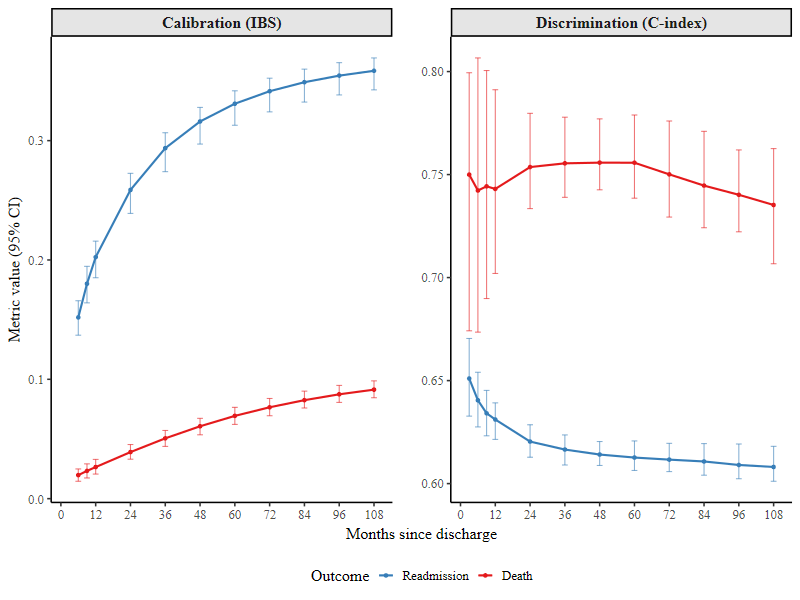

In [ ]:
#| label: cindex-ibs-plot-ml-informed

tnr <- "Times New Roman"
set1_colors <- RColorBrewer::brewer.pal(n = 3, name = "Set1") # Set1 has up to 9 colors, but you only need 2
set1_colors <- rev(set1_colors[1:2])

# Prepare data (ensure proper extraction from results)
time_metrics <- results_boot$summary %>%
  filter(Time != "Global") %>%
  mutate(Time_num = as.numeric(as.character(Time)),
         # Ensure proper ordering of Risk factors
         Risk = factor(Risk, levels = c("Readmission", "Death")))

# Split by metric for separate panels or plots
cindex_data <- time_metrics %>% filter(Metric == "Uno's C-Index")
ibs_data <- time_metrics %>% filter(Metric == "IBS")


p_faceted <- time_metrics %>%
  mutate(Metric = ifelse(Metric == "Uno's C-Index", "Discrimination (C-index)", "Calibration (IBS)")) %>%
  ggplot(aes(x = Time_num, y = mean, color = Risk, fill = Risk)) +
  geom_line(linewidth = 1) +
  geom_point(size = 1.5) +
  geom_errorbar(aes(ymin = q025, ymax = q975), width = 2, alpha = 0.6, size = 0.5) +
  facet_wrap(~Metric, scales = "free_y", ncol = 2) +
  scale_color_manual(values = set1_colors) +
  scale_fill_manual(values = set1_colors) +
  scale_x_continuous(breaks = seq(0, 108, by = 12)) +
  labs(x = "Months since discharge",
       y = "Metric value (95% CI)",
       color = "Outcome",
       fill = "Outcome") +
  theme_classic(base_size = 16, base_family= tnr) +
  theme(legend.position = "bottom",
        strip.background = element_rect(fill = "grey90", color = "black"),
        strip.text = element_text(face = "bold", size = 16),
        panel.spacing = unit(2, "lines"))

p_faceted

In [ ]:
#| label: cindex-ibs-cv5-full-ph-cox

results_boot_full <- evaluate_dual_cox_python_style(
  formula_readmit = formula_readmit_updated2,
  formula_death = formula_death_updated2,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3, 6, 9, 12, 24, 36, 48, 60, 72, 84, 96, 108)
)

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....


In [ ]:
#| label: cindex-ibs-global-summary-full-ph-cox

results_boot_full$summary |> dplyr::filter( Time == "Global") |> 
  knitr::kable("markdown", caption= "Global C-index and IBS summary, Full PH‑adjusted Cox with stratification")




Table: Global C-index and IBS summary, Full PH‑adjusted Cox with stratification

|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Death       |IBS           |Global | 0.0905991| 0.0040646| 0.0839322| 0.0981021| 25|
|Death       |Uno's C-Index |Global | 0.7423727| 0.0107173| 0.7237427| 0.7604639| 25|
|Readmission |IBS           |Global | 0.3580220| 0.0078879| 0.3418346| 0.3684389| 25|
|Readmission |Uno's C-Index |Global | 0.6040678| 0.0055152| 0.5949062| 0.6146601| 25|

Warning messages:
1: Removed 2 rows containing missing values or values outside the scale range (`geom_line()`). 
2: Removed 2 rows containing missing values or values outside the scale range (`geom_point()`). 


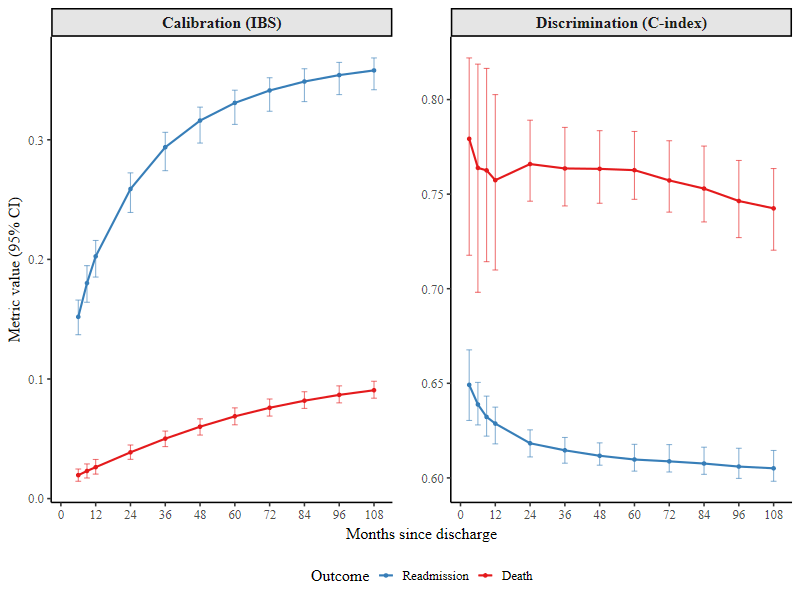

In [ ]:
#| label: cindex-ibs-plot-full-ph-cox

# Prepare data (ensure proper extraction from results)
time_metrics_full <- results_boot_full$summary %>%
  filter(Time != "Global") %>%
  mutate(Time_num = as.numeric(as.character(Time)),
         # Ensure proper ordering of Risk factors
         Risk = factor(Risk, levels = c("Readmission", "Death")))

# Split by metric for separate panels or plots
cindex_data_full <- time_metrics_full %>% filter(Metric == "Uno's C-Index")
ibs_data_full <- time_metrics_full %>% filter(Metric == "IBS")


p_faceted_full <- time_metrics_full %>%
  mutate(Metric = ifelse(Metric == "Uno's C-Index", "Discrimination (C-index)", "Calibration (IBS)")) %>%
  ggplot(aes(x = Time_num, y = mean, color = Risk, fill = Risk)) +
  geom_line(linewidth = 1) +
  geom_point(size = 1.5) +
  geom_errorbar(aes(ymin = q025, ymax = q975), width = 2, alpha = 0.6, size = 0.5) +
  facet_wrap(~Metric, scales = "free_y", ncol = 2) +
  scale_color_manual(values = set1_colors) +
  scale_fill_manual(values = set1_colors) +
  scale_x_continuous(breaks = seq(0, 108, by = 12)) +
  labs(x = "Months since discharge",
       y = "Metric value (95% CI)",
       color = "Outcome",
       fill = "Outcome") +
  theme_classic(base_size = 16, base_family= tnr) +
  theme(legend.position = "bottom",
        strip.background = element_rect(fill = "grey90", color = "black"),
        strip.text = element_text(face = "bold", size = 16),
        panel.spacing = unit(2, "lines"))

p_faceted_full

### Calibration plots

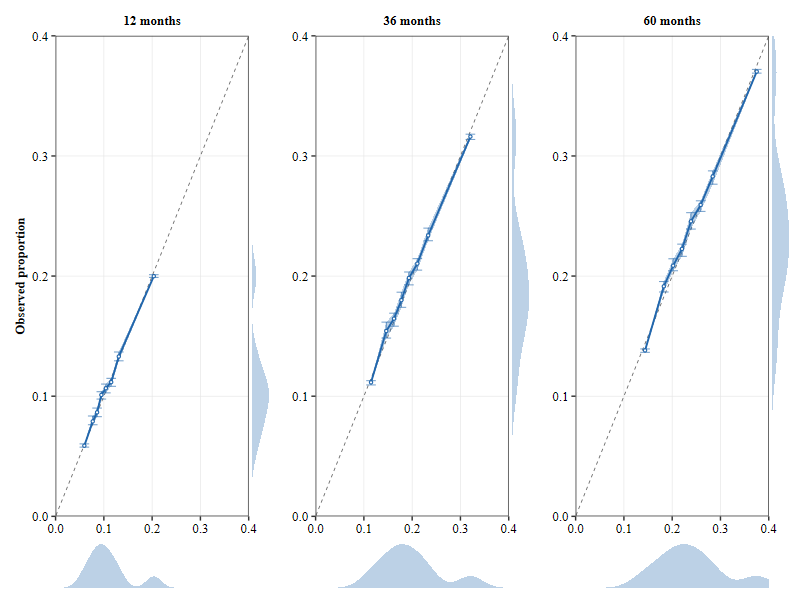

Calibration plots saved to: G:/My Drive/Alvacast/SISTRAT 2023/cons/_figs/readmission_calibration_full_marginal.tiff


In [ ]:
#| label: calibration-plot-full-ph-cox-readm

library(ggplot2)
library(dplyr)
library(patchwork)

cal_full_data <- cal_readmit_full_aj_rcv$calibration_curves |>
  dplyr::mutate(time_label = paste0(time_months, " months"))

create_cal_published <- function(data, time_title, show_x_label = FALSE, show_y_label = FALSE) {
  
  # FIXED identical margins for all plots to ensure alignment
  # Order: top, right, bottom, left
  fixed_margin <- margin(5, 2, 5, 5)  # Extra space reserved for labels
  
  main <- ggplot(data, aes(x = mean_predicted, y = observed)) +
    geom_abline(intercept = 0, slope = 1, linetype = "dashed", 
                color = "black", linewidth = 0.4, alpha = 0.6) +
    geom_ribbon(aes(ymin = observed_min, ymax = observed_max), 
                alpha = 0.3, fill = "#2166AC") +
    geom_line(color = "#2166AC", linewidth = 0.9) +
    geom_errorbar(aes(ymin = observed_min, ymax = observed_max), 
                  width = 0.02, color = "#2166AC", alpha = 0.6, linewidth = 0.5) +
    geom_point(size = 1, color = "#2166AC", fill = "white", 
               shape = 21, stroke = 0.8) +
    scale_x_continuous(limits = c(0, 0.4), expand = c(0, 0), 
                       breaks = seq(0, 0.4, by = 0.1),
                       labels = scales::number_format(accuracy = 0.1)) +
    scale_y_continuous(limits = c(0, 0.4), expand = c(0, 0), 
                       breaks = seq(0, 0.4, by = 0.1)) +
    labs(
      x = NULL, #"Predicted probability", 
      y = "Observed proportion", 
      subtitle = time_title
    ) +
    theme_bw(base_size = 15, base_family= tnr) +
    theme(
      plot.subtitle = element_text(size = 13, face = "bold", hjust = 0.5),#element_blank(),
      panel.grid.major = element_line(color = "grey90", linewidth = 0.3),
      panel.grid.minor = element_blank(),
      axis.ticks.length = unit(1.5, "mm"),
      axis.text = element_text(size = 13, color = "black"),
      axis.title = element_text(size = 13, face = "bold"),
      # Use color = NA to hide labels while PRESERVING SPACE (maintains alignment)
      axis.title.x = element_text(
        color = if(show_x_label) "black" else NA,
        size = 13, face = "bold"
      ),
      axis.title.y = element_text(
        color = if(show_y_label) "black" else NA,
        size = 13, face = "bold"
      ),
      plot.margin = fixed_margin  # IDENTICAL for every plot
    )
    
  # Margins aligned to main plot
  right_dens <- ggplot(data, aes(x = observed)) +
    geom_density(fill = "#2166AC", alpha = 0.3, color = NA) +
    scale_x_continuous(limits = c(0, 0.4), expand = c(0, 0)) +
    coord_flip() +
    theme_void() +
    theme(plot.margin = margin(5, 0, 5, 0))  # Match main top/bottom
    
  bottom_dens <- ggplot(data, aes(x = mean_predicted)) +
    geom_density(fill = "#2166AC", alpha = 0.3, color = NA) +
    scale_x_continuous(limits = c(0, 0.4), expand = c(0, 0)) +
    theme_void() +
    theme(plot.margin = margin(0, 2, 0, 5))  # Match main right/left
    
  design <- c(
    area(t = 1, l = 1, b = 10, r = 10),
    area(t = 1, l = 11, b = 10, r = 11),
    area(t = 11, l = 1, b = 11, r = 10)
  )
    
  main + right_dens + bottom_dens + 
    plot_layout(design = design)
}

# Determine label positions
time_levels_full <- paste0(sort(unique(cal_full_data$time_months)), " months")
n_plots <- length(time_levels_full)
n_cols <- 3
n_rows <- ceiling(n_plots / n_cols)

plots_full <- lapply(seq_along(time_levels_full), function(i) {
  col_idx <- (i - 1) %% n_cols      # 0 = left, 1 = middle, 2 = right
  row_idx <- (i - 1) %/% n_cols     # 0 = top, etc.
  
  # Left column gets Y-label
  show_y <- col_idx == 0
  
  # Bottom row, middle position gets X-label
  is_last_row <- row_idx == (n_rows - 1)
  n_in_last_row <- n_plots - (n_rows - 1) * n_cols
  middle_idx <- floor((n_in_last_row - 1) / 2)
  show_x <- is_last_row && (col_idx == middle_idx)
  
  create_cal_published(
    cal_full_data %>% filter(time_label == time_levels_full[i]), 
    time_levels_full[i],
    show_x_label = show_x,
    show_y_label = show_y
  )
})

combined_full <- wrap_plots(plots_full, ncol = 3) +
  plot_annotation(
    theme = theme(plot.margin = margin(10, 10, 10, 10))
  )

print(combined_full)

ggsave(paste0(project_root,"/cons/_figs/readmission_calibration_full_marginal.tiff"), 
combined_full, 
       width = 17.8*1.4, height = 6*1.6, units = "cm", 
       dpi = 600, compression = "lzw")
ggsave(paste0(project_root,"/cons/_figs/readmission_calibration_full_marginal.png"), 
combined_full, 
       width = 17.8*1.4, height = 6*1.6, units = "cm", 
       dpi = 600)
message("Calibration plots saved to: ", paste0(project_root,"/cons/_figs/readmission_calibration_full_marginal.tiff"))

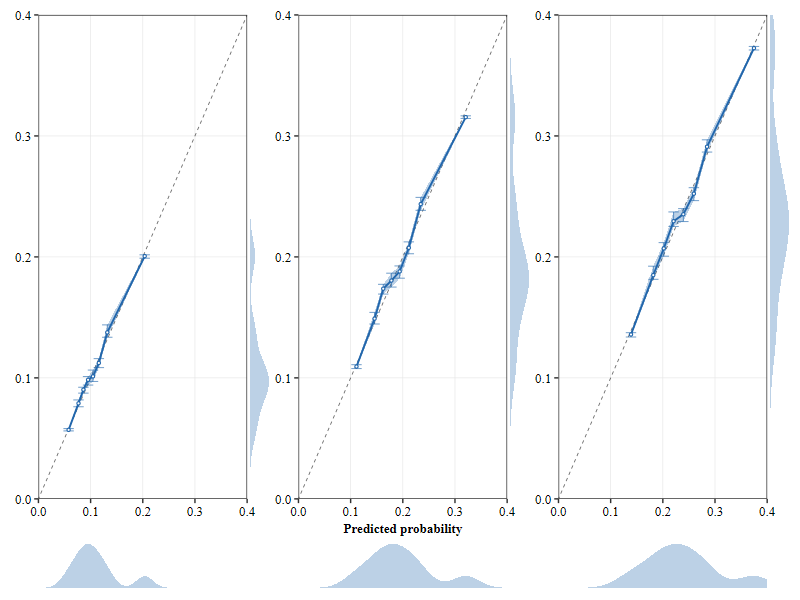

Calibration plots saved to: G:/My Drive/Alvacast/SISTRAT 2023/cons/_figs/readmission_calibration_marginal.tiff


In [ ]:
#| label: calibration-plot-ml-informed-readm

cal_data <- cal_readmit_aj_rcv$calibration_curves |>
  dplyr::mutate(time_label = paste0(time_months, " months"))

create_cal_published <- function(data, time_title, show_x_label = FALSE, show_y_label = FALSE) {
  
  # FIXED identical margins for all plots to ensure alignment
  # Order: top, right, bottom, left
  fixed_margin <- margin(5, 2, 5, 5)  # Extra space reserved for labels
  
  main <- ggplot(data, aes(x = mean_predicted, y = observed)) +
    geom_abline(intercept = 0, slope = 1, linetype = "dashed", 
                color = "black", linewidth = 0.4, alpha = 0.6) +
    geom_ribbon(aes(ymin = observed_min, ymax = observed_max), 
                alpha = 0.3, fill = "#2166AC") +
    geom_line(color = "#2166AC", linewidth = 0.9) +
    geom_errorbar(aes(ymin = observed_min, ymax = observed_max), 
                  width = 0.02, color = "#2166AC", alpha = 0.6, linewidth = 0.5) +
    geom_point(size = 1, color = "#2166AC", fill = "white", 
               shape = 21, stroke = 0.8) +
    scale_x_continuous(limits = c(0, 0.4), expand = c(0, 0), 
                       breaks = seq(0, 0.4, by = 0.1),
                       labels = scales::number_format(accuracy = 0.1)) +
    scale_y_continuous(limits = c(0, 0.4), expand = c(0, 0), 
                       breaks = seq(0, 0.4, by = 0.1)) +
    labs(
      x = "Predicted probability", 
      y = NULL, #"Observed proportion", 
      subtitle = time_title
    ) +
    theme_bw(base_size = 15, base_family= tnr)+
    theme(
      plot.subtitle = element_blank(),
      panel.grid.major = element_line(color = "grey90", linewidth = 0.3),
      panel.grid.minor = element_blank(),
      axis.ticks.length = unit(1.5, "mm"),
      axis.text = element_text(size = 13, color = "black"),
      axis.title = element_text(size = 13, face = "bold"),
      # Use color = NA to hide labels while PRESERVING SPACE (maintains alignment)
      axis.title.x = element_text(
        color = if(show_x_label) "black" else NA,
        size = 13, face = "bold"
      ),
      axis.title.y = element_text(
        color = if(show_y_label) "black" else NA,
        size = 13, face = "bold"
      ),
      plot.margin = fixed_margin  # IDENTICAL for every plot
    )
    
  # Margins aligned to main plot
  right_dens <- ggplot(data, aes(x = observed)) +
    geom_density(fill = "#2166AC", alpha = 0.3, color = NA) +
    scale_x_continuous(limits = c(0, 0.4), expand = c(0, 0)) +
    coord_flip() +
    theme_void() +
    theme(plot.margin = margin(5, 0, 5, 0))  # Match main top/bottom
    
  bottom_dens <- ggplot(data, aes(x = mean_predicted)) +
    geom_density(fill = "#2166AC", alpha = 0.3, color = NA) +
    scale_x_continuous(limits = c(0, 0.4), expand = c(0, 0)) +
    theme_void() +
    theme(plot.margin = margin(0, 2, 0, 5))  # Match main right/left
    
  design <- c(
    area(t = 1, l = 1, b = 10, r = 10),
    area(t = 1, l = 11, b = 10, r = 11),
    area(t = 11, l = 1, b = 11, r = 10)
  )
    
  main + right_dens + bottom_dens + 
    plot_layout(design = design)
}

# Determine label positions
time_levels <- paste0(sort(unique(cal_data$time_months)), " months")
n_plots <- length(time_levels)
n_cols <- 3
n_rows <- ceiling(n_plots / n_cols)

plots <- lapply(seq_along(time_levels), function(i) {
  col_idx <- (i - 1) %% n_cols      # 0 = left, 1 = middle, 2 = right
  row_idx <- (i - 1) %/% n_cols     # 0 = top, etc.
  
  # Left column gets Y-label
  show_y <- col_idx == 0
  
  # Bottom row, middle position gets X-label
  is_last_row <- row_idx == (n_rows - 1)
  n_in_last_row <- n_plots - (n_rows - 1) * n_cols
  middle_idx <- floor((n_in_last_row - 1) / 2)
  show_x <- is_last_row && (col_idx == middle_idx)
  
  create_cal_published(
    cal_data %>% filter(time_label == time_levels[i]), 
    time_levels[i],
    show_x_label = show_x,
    show_y_label = show_y
  )
})

combined <- wrap_plots(plots, ncol = 3) +
  plot_annotation(
    theme = theme(plot.margin = margin(10, 10, 10, 10))
  )

print(combined)

ggsave(paste0(project_root,"/cons/_figs/readmission_calibration_marginal.tiff"), 
combined, 
       width = 17.8*1.4, height = 6*1.6, units = "cm", 
       dpi = 600, compression = "lzw")
ggsave(paste0(project_root,"/cons/_figs/readmission_calibration_marginal.png"), 
combined, 
       width = 17.8*1.4, height = 6*1.6, units = "cm", 
       dpi = 600)
message("Calibration plots saved to: ", paste0(project_root,"/cons/_figs/readmission_calibration_marginal.tiff"))

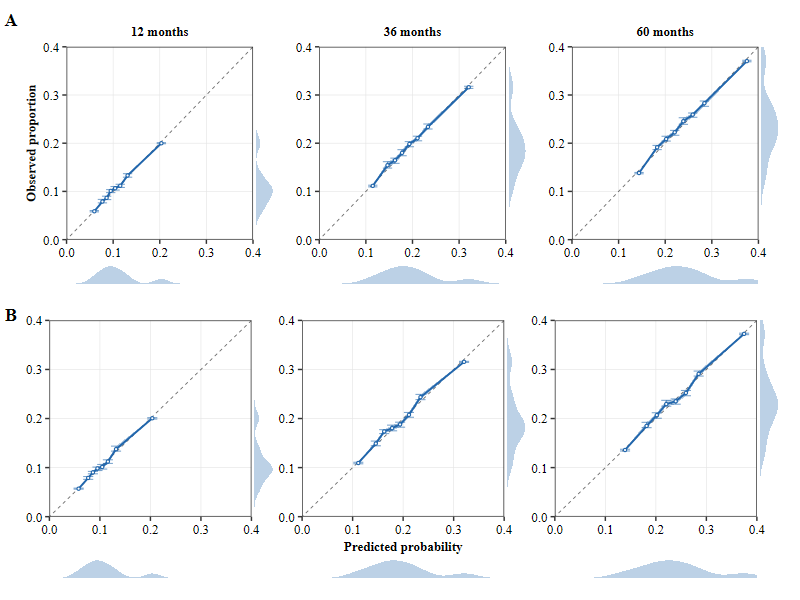

In [ ]:
#| label: calibration-plot-combined-readm
library(patchwork)

final_figure_readm <- wrap_plots(
  wrap_elements(combined_full),
  wrap_elements(combined),
  ncol = 1
) + 
  plot_annotation(tag_levels = "A") & 
  theme(plot.tag = element_text(face = "bold", size = 18, family = "Times New Roman"),
    plot.tag.position = c(0.00, 0.97))

print(final_figure_readm)

ggsave(paste0(project_root,"/cons/_figs/readmission_calibration_combined_AB.tiff"), 
       final_figure_readm, 
       width = 17.8*1.4, height = 12*1.6, units = "cm",
       dpi = 600, compression = "lzw")
ggsave(paste0(project_root,"/cons/_figs/readmission_calibration_combined_AB.png"), 
       final_figure_readm, 
       width = 17.8*1.4, height = 12*1.6, units = "cm",
       dpi = 600)

### Mortality, calibration plots

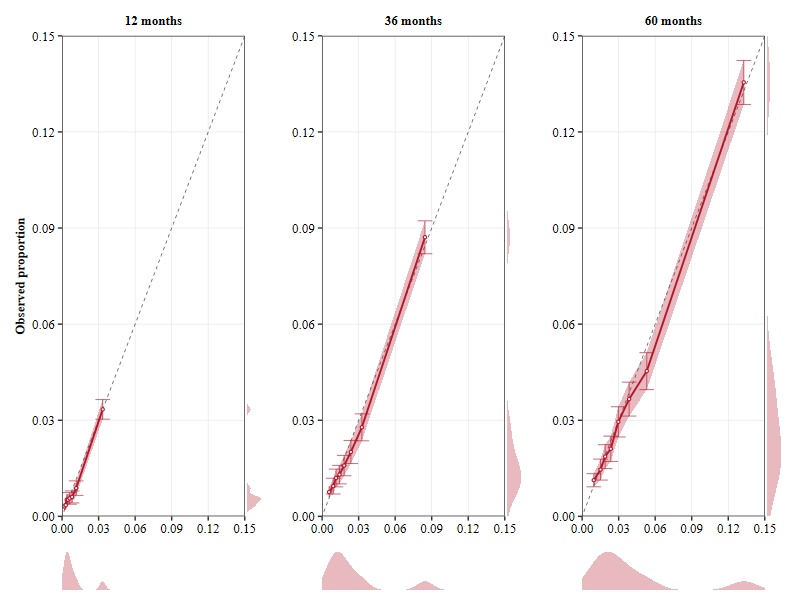

Calibration plots saved to: G:/My Drive/Alvacast/SISTRAT 2023/cons/_figs/mortality_calibration_full_marginal.tiff


In [ ]:
#| label: calibration-plot-full-ph-cox-death
cal_data_full_death <- cal_death_full_ici$calibration_curves |>
  dplyr::mutate(
    time_label = paste0(time_months, " months"),
    observed_min = observed_lower,
    observed_max = observed_upper
  )

create_cal_death_published <- function(data, time_title, show_x_label = FALSE, show_y_label = FALSE) {
  
  # FIXED margins for all plots
  fixed_margin <- margin(5, 2, 5, 5)
  
  main <- ggplot(data, aes(x = mean_predicted, y = observed)) +
    geom_abline(intercept = 0, slope = 1, linetype = "dashed", 
                color = "black", linewidth = 0.4, alpha = 0.6) +
    geom_ribbon(aes(ymin = observed_min, ymax = observed_max), 
                alpha = 0.3, fill = "#B2182B") +
    geom_line(color = "#B2182B", linewidth = 0.9) +
    geom_errorbar(aes(ymin = observed_min, ymax = observed_max), 
                  width = 0.012, color = "#B2182B", alpha = 0.6, linewidth = 0.5) +
    geom_point(size = 1, color = "#B2182B", fill = "white", 
               shape = 21, stroke = 0.8) +
    scale_x_continuous(limits = c(0, 0.15), expand = c(0, 0), 
                       breaks = seq(0, 0.15, by = 0.03)) +
    scale_y_continuous(limits = c(0, 0.15), expand = c(0, 0), 
                       breaks = seq(0, 0.15, by = 0.03)) +
    labs(
      x = NULL, #"Predicted probability", 
      y = "Observed proportion", 
      subtitle = time_title
    ) +
    theme_bw(base_size = 15, base_family= tnr) +
    theme(
      plot.subtitle = element_text(size = 13, face = "bold", hjust = 0.5),
      panel.grid.major = element_line(color = "grey90", linewidth = 0.3),
      panel.grid.minor = element_blank(),
      axis.ticks.length = unit(1.5, "mm"),
      axis.text = element_text(size = 13, color = "black"),
      axis.title = element_text(size = 13, face = "bold"),
      axis.title.x = element_text(color = if(show_x_label) "black" else "transparent"),
      axis.title.y = element_text(color = if(show_y_label) "black" else "transparent"),
      plot.margin = fixed_margin
    )
    
  # RIGHT DENSITY - Fixed truncation with expansion on density axis
  right_dens <- ggplot(data, aes(x = observed)) +
    geom_density(fill = "#B2182B", alpha = 0.3, color = NA) +
    # Set observed limits (will become y-axis after flip)
    scale_x_continuous(limits = c(0, 0.15), expand = c(0, 0)) +
    # CRITICAL: Add expansion to density axis (becomes x-axis after flip) to prevent truncation
    scale_y_continuous(expand = expansion(mult = c(0, 0.25))) +  # 25% padding on top
    coord_flip() +
    theme_void() +
    theme(plot.margin = margin(5, 5, 5, 0))  # Match main plot top/bottom (5)
    
  # BOTTOM DENSITY - Fixed truncation  
  bottom_dens <- ggplot(data, aes(x = mean_predicted)) +
    geom_density(fill = "#B2182B", alpha = 0.3, color = NA) +
    # Set limits to match main plot x-axis
    scale_x_continuous(limits = c(0, 0.15), expand = c(0, 0)) +
    # CRITICAL: Add expansion to density axis (y-axis) to prevent truncation
    scale_y_continuous(expand = expansion(mult = c(0, 0.25))) +  # 25% padding on top
    theme_void() +
    theme(plot.margin = margin(0, 2, 0, 5))  # Match main right/left
  
  # Alternative: Use clip = "off" with expanded limits if expansion doesn't work
  # right_dens <- ggplot(data, aes(x = observed)) +
  #   geom_density(fill = "#B2182B", alpha = 0.3, color = NA) +
  #   scale_x_continuous(limits = c(0, 0.15), expand = c(0, 0)) +
  #   coord_flip(clip = "off") +
  #   theme_void() +
  #   theme(plot.margin = margin(5, 15, 5, 0))  # Extra right margin (15) for density peak
    
  design <- c(
    area(t = 1, l = 1, b = 10, r = 10),
    area(t = 1, l = 11, b = 10, r = 11),
    area(t = 11, l = 1, b = 11, r = 10)
  )
    
  main + right_dens + bottom_dens + 
    plot_layout(design = design)
}

# Generate plots with selective labels (same logic as before)
time_levels_full <- paste0(sort(unique(cal_data_full_death$time_months)), " months")
n_plots_full <- length(time_levels_full)
n_cols <- 3
n_rows <- ceiling(n_plots_full / n_cols)

plots_death_full <- lapply(seq_along(time_levels_full), function(i) {
  col_idx <- (i - 1) %% n_cols      
  row_idx <- (i - 1) %/% n_cols     
  
  show_y <- col_idx == 0
  
  is_last_row <- row_idx == (n_rows - 1)
  n_in_last_row <- n_plots_full - (n_rows - 1) * n_cols
  middle_idx <- floor((n_in_last_row - 1) / 2)
  show_x <- is_last_row && (col_idx == middle_idx)
  
  create_cal_death_published(
    cal_data_full_death %>% filter(time_label == time_levels_full[i]), 
    time_levels_full[i],
    show_x_label = show_x,
    show_y_label = show_y
  )
})

combined_death_full <- wrap_plots(plots_death_full, ncol = 3) +
  plot_annotation(
    theme = theme(plot.margin = margin(10, 10, 10, 10))
  )

print(combined_death_full)

ggsave(paste0(project_root,"/cons/_figs/mortality_calibration_full_marginal.tiff"), 
       combined_death_full, 
       width = 17.8*1.4, height = 6*1.6, units = "cm", 
       dpi = 600, compression = "lzw")

ggsave(paste0(project_root,"/cons/_figs/mortality_calibration_full_marginal.png"), 
       combined_death_full, 
       width = 17.8*1.4, height = 6*1.6, units = "cm", 
       dpi = 600)
message("Calibration plots saved to: ", paste0(project_root,"/cons/_figs/mortality_calibration_full_marginal.tiff"))

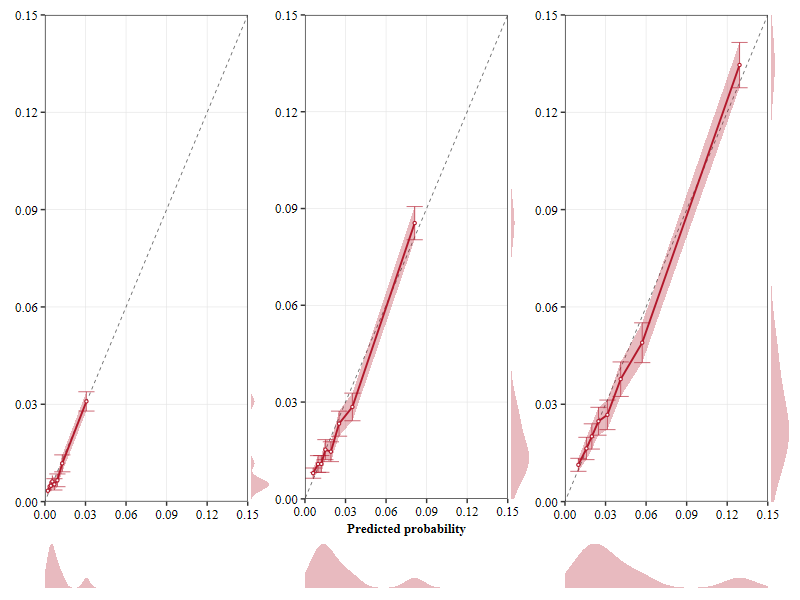

Calibration plots saved to: G:/My Drive/Alvacast/SISTRAT 2023/cons/_figs/mortality_calibration_marginal.tiff


In [ ]:
#| label: calibration-plot-ml-informed-death
cal_data_death <- cal_death_ici$calibration_curves |>
  dplyr::mutate(
    time_label = paste0(time_months, " months"),
    observed_min = observed_lower,
    observed_max = observed_upper
  )

create_cal_death_published <- function(data, time_title, show_x_label = FALSE, show_y_label = FALSE) {
  main <- ggplot(data, aes(x = mean_predicted, y = observed)) +
    geom_abline(intercept = 0, slope = 1, linetype = "dashed", 
                color = "black", linewidth = 0.4, alpha = 0.6) +
    geom_ribbon(aes(ymin = observed_min, ymax = observed_max), 
                alpha = 0.3, fill = "#B2182B") +
    geom_line(color = "#B2182B", linewidth = 0.9) +
    geom_errorbar(aes(ymin = observed_min, ymax = observed_max), 
                  width = 0.012, color = "#B2182B", alpha = 0.6, linewidth = 0.5) +
    geom_point(size = 1, color = "#B2182B", fill = "white", 
               shape = 21, stroke = 0.8) +
    scale_x_continuous(limits = c(0, 0.15), expand = c(0, 0), 
                       breaks = seq(0, 0.15, by = 0.03)) +
    scale_y_continuous(limits = c(0, 0.15), expand = c(0, 0), 
                       breaks = seq(0, 0.15, by = 0.03)) +
    labs(
      x = if(show_x_label) "Predicted probability" else "Predicted probability",
      y = if(show_y_label) NULL,#"Observed proportion" else NULL,
      subtitle = time_title
    ) +
    theme_bw(base_size = 15, base_family = tnr) +
    theme(
      plot.subtitle = element_blank(),#element_text(size = 13, face = "bold"),
      panel.grid.major = element_line(color = "grey90", linewidth = 0.3),
      panel.grid.minor = element_blank(),
      axis.ticks.length = unit(1.5, "mm"),
      axis.text = element_text(size = 13, color = "black"),
      axis.title = element_text(size = 13, face = "bold"),
      # Tighter margins when no label to prevent gaps
      plot.margin = margin(
        5, 
        2, 
        if(show_x_label) 5 else 2,  # Bottom: larger if label present
        if(show_y_label) 5 else 2   # Left: larger if label present
      )
    )+
    theme(
      axis.title.x = element_text(color = if(show_x_label) "black" else "transparent")
    )
    
  right_dens <- ggplot(data, aes(x = observed)) +
    geom_density(fill = "#B2182B", alpha = 0.3, color = NA) +
    scale_x_continuous(limits = c(0, 0.15), expand = c(0, 0)) +
    coord_flip() +
    theme_void() +
    theme(plot.margin = margin(5, 0, 2, 0))
    
  bottom_dens <- ggplot(data, aes(x = mean_predicted)) +
    geom_density(fill = "#B2182B", alpha = 0.3, color = NA) +
    scale_x_continuous(limits = c(0, 0.15), expand = c(0, 0)) +
    theme_void() +
    theme(plot.margin = margin(0, 2, 0, 5))
    
  design <- c(
    area(t = 1, l = 1, b = 10, r = 10),
    area(t = 1, l = 11, b = 10, r = 11),
    area(t = 11, l = 1, b = 11, r = 10)
  )
    
  main + right_dens + bottom_dens + 
    plot_layout(design = design)
}

# Determine label positions
time_levels <- paste0(sort(unique(cal_data_death$time_months)), " months")
n_plots <- length(time_levels)
n_cols <- 3
n_rows <- ceiling(n_plots / n_cols)

plots_death <- lapply(seq_along(time_levels), function(i) {
  # Calculate grid position (0-indexed)
  col_idx <- (i - 1) %% n_cols      # 0 = left, 1 = middle, 2 = right
  row_idx <- (i - 1) %/% n_cols     # 0 = top row, etc.
  
  # Left column gets Y-label
  show_y <- col_idx == 0
  
  # Bottom row, middle position gets X-label
  is_last_row <- row_idx == (n_rows - 1)
  n_in_last_row <- n_plots - (n_rows - 1) * n_cols
  middle_idx <- floor((n_in_last_row - 1) / 2)  # 0 for 1 plot, 0 for 2 plots, 1 for 3 plots
  show_x <- is_last_row && (col_idx == middle_idx)
  
  create_cal_death_published(
    cal_data_death %>% filter(time_label == time_levels[i]), 
    time_levels[i],
    show_x_label = show_x,
    show_y_label = show_y
  )
})

combined_death <- wrap_plots(plots_death, ncol = 3) +
  plot_annotation(
    theme = theme(plot.margin = margin(10, 10, 10, 10))
  )

print(combined_death)

ggsave(paste0(project_root,"/cons/_figs/mortality_calibration_marginal.tiff"), 
combined_death, 
       width = 17.8*1.4, height = 6*1.6, units = "cm", 
       dpi = 600, compression = "lzw")

ggsave(paste0(project_root,"/cons/_figs/mortality_calibration_marginal.png"), 
combined_death, 
       width = 17.8*1.4, height = 6*1.6, units = "cm", 
       dpi = 600)
message("Calibration plots saved to: ", paste0(project_root,"/cons/_figs/mortality_calibration_marginal.tiff"))

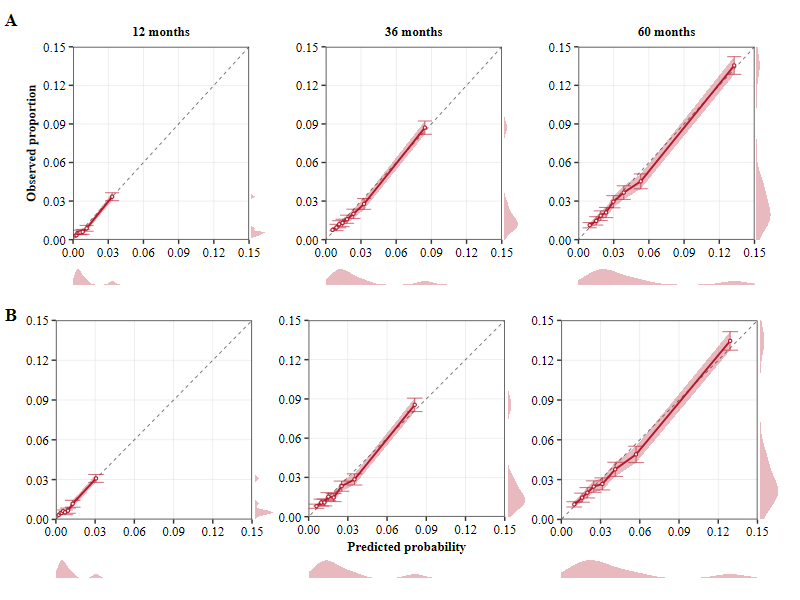

In [ ]:
#| label: calibration-plot-combined-death
final_figure <- wrap_plots(
  wrap_elements(combined_death_full),
  wrap_elements(combined_death),
  ncol = 1
) + 
  plot_annotation(tag_levels = "A") & 
  theme(plot.tag = element_text(face = "bold", size = 18, family = "Times New Roman"),
    plot.tag.position = c(0.00, 0.97))

print(final_figure)

ggsave(paste0(project_root,"/cons/_figs/mortality_calibration_combined_AB.tiff"), 
       final_figure, 
       width = 17.8*1.4, height = 12*1.6, units = "cm",
       dpi = 600, compression = "lzw")
ggsave(paste0(project_root,"/cons/_figs/mortality_calibration_combined_AB.png"), 
       final_figure, 
       width = 17.8*1.4, height = 12*1.6, units = "cm",
       dpi = 600)

## DCA

In [ ]:
#| label: dca-summary-obtain

source(paste0(project_root,"/cons/_hist_scripts/adca_from_results_boot.R"))
adca_out <- run_adca_from_results_boot(results_boot)
adca_out_full <- run_adca_from_results_boot(results_boot_full)

In [ ]:
#| label: dca-summary-function

dca_summary_clean <- dplyr::mutate(
  adca_out$summary,
  strategy = dplyr::recode(
    strategy,
    "Model" = "model",
    "Treat all" = "treat_all",
    "Treat none" = "treat_none"
  )
)

base::table(dca_summary_clean$strategy, useNA = "ifany")

dca_nb <- tidyr::pivot_wider(
  data = dplyr::select(
    dca_summary_clean,
    risk,
    horizon,
    threshold,
    observed_event_risk_mean,
    focus_lower,
    focus_upper,
    in_focus_window,
    strategy,
    net_benefit_mean
  ),
  id_cols = c(
    risk,
    horizon,
    threshold,
    observed_event_risk_mean,
    focus_lower,
    focus_upper,
    in_focus_window
  ),
  names_from = strategy,
  values_from = net_benefit_mean,
  names_prefix = "nb_"
)

dca_nb <- dplyr::mutate(
  dca_nb,
  model_beats_none = !is.na(nb_model) &
    !is.na(nb_treat_none) &
    (nb_model > nb_treat_none),
  model_beats_all = !is.na(nb_model) &
    !is.na(nb_treat_all) &
    (nb_model > nb_treat_all),
  model_useful = model_beats_none & model_beats_all
)

dca_any_useful_anywhere <- dca_nb |>
  dplyr::group_by(risk, horizon) |>
  dplyr::summarise(
    any_useful_anywhere = any(model_useful, na.rm = TRUE),
    useful_threshold_min = if (any(model_useful, na.rm = TRUE)) {
      min(threshold[model_useful], na.rm = TRUE)
    } else {
      NA_real_
    },
    useful_threshold_max = if (any(model_useful, na.rm = TRUE)) {
      max(threshold[model_useful], na.rm = TRUE)
    } else {
      NA_real_
    },
    max_model_nb = max(nb_model, na.rm = TRUE),
    max_treat_all_nb = max(nb_treat_all, na.rm = TRUE),
    max_treat_none_nb = max(nb_treat_none, na.rm = TRUE),
    .groups = "drop"
  ) |>
  dplyr::arrange(risk, horizon)

dca_focus_summary <- dca_nb |>
  dplyr::filter(in_focus_window, model_useful) |>
  dplyr::group_by(risk, horizon, focus_lower, focus_upper, observed_event_risk_mean) |>
  dplyr::summarise(
    useful_threshold_min = min(threshold, na.rm = TRUE),
    useful_threshold_max = max(threshold, na.rm = TRUE),
    peak_nb = max(nb_model, na.rm = TRUE),
    .groups = "drop"
  ) |>
  dplyr::arrange(risk, horizon)

#dca_any_useful_anywhere


In [ ]:
#| label: dca-summary-full-function

dca_summary_clean_full <- dplyr::mutate(
  adca_out_full$summary,
  strategy = dplyr::recode(
    strategy,
    "Model" = "model",
    "Treat all" = "treat_all",
    "Treat none" = "treat_none"
  )
)

base::table(dca_summary_clean_full$strategy, useNA = "ifany")

dca_nb_full <- tidyr::pivot_wider(
  data = dplyr::select(
    dca_summary_clean_full,
    risk,
    horizon,
    threshold,
    observed_event_risk_mean,
    focus_lower,
    focus_upper,
    in_focus_window,
    strategy,
    net_benefit_mean
  ),
  id_cols = c(
    risk,
    horizon,
    threshold,
    observed_event_risk_mean,
    focus_lower,
    focus_upper,
    in_focus_window
  ),
  names_from = strategy,
  values_from = net_benefit_mean,
  names_prefix = "nb_"
)

dca_nb_full <- dplyr::mutate(
  dca_nb_full,
  model_beats_none = !is.na(nb_model) &
    !is.na(nb_treat_none) &
    (nb_model > nb_treat_none),
  model_beats_all = !is.na(nb_model) &
    !is.na(nb_treat_all) &
    (nb_model > nb_treat_all),
  model_useful = model_beats_none & model_beats_all
)

dca_any_useful_anywhere_full <- dca_nb_full |>
  dplyr::group_by(risk, horizon) |>
  dplyr::summarise(
    any_useful_anywhere = any(model_useful, na.rm = TRUE),
    useful_threshold_min = if (any(model_useful, na.rm = TRUE)) {
      min(threshold[model_useful], na.rm = TRUE)
    } else {
      NA_real_
    },
    useful_threshold_max = if (any(model_useful, na.rm = TRUE)) {
      max(threshold[model_useful], na.rm = TRUE)
    } else {
      NA_real_
    },
    max_model_nb = max(nb_model, na.rm = TRUE),
    max_treat_all_nb = max(nb_treat_all, na.rm = TRUE),
    max_treat_none_nb = max(nb_treat_none, na.rm = TRUE),
    .groups = "drop"
  ) |>
  dplyr::arrange(risk, horizon)

dca_focus_summary_full <- dca_nb_full |>
  dplyr::filter(in_focus_window, model_useful) |>
  dplyr::group_by(risk, horizon, focus_lower, focus_upper, observed_event_risk_mean) |>
  dplyr::summarise(
    useful_threshold_min = min(threshold, na.rm = TRUE),
    useful_threshold_max = max(threshold, na.rm = TRUE),
    peak_nb = max(nb_model, na.rm = TRUE),
    .groups = "drop"
  ) |>
  dplyr::arrange(risk, horizon)

#dca_any_useful_anywhere_full


In [ ]:
#| label: dca-plot-function
make_dca_panel_figure <- function(summary_full,
                                  summary_ml,
                                  outcome = c("death", "readmission"),
                                  horizons = c(12, 36, 60),
                                  x_limits = NULL,
                                  y_limits = NULL) {
  
  outcome <- base::match.arg(outcome)
  
  full_dat <- summary_full
  ml_dat   <- summary_ml
  
  full_dat$model_panel <- "A"
  ml_dat$model_panel   <- "B"
  
  plot_dat <- base::rbind(full_dat, ml_dat)
  
  plot_dat <- plot_dat[
    plot_dat$risk %in% outcome &
      plot_dat$horizon %in% horizons,
    ,
    drop = FALSE
  ]
  
  plot_dat$strategy_plot <- ifelse(
    plot_dat$strategy == "Model",
    "Model",
    plot_dat$strategy
  )
  
  plot_dat <- plot_dat[, c(
    "risk", "horizon", "threshold", "model_panel",
    "strategy_plot", "net_benefit_mean",
    "focus_lower", "focus_upper"
  )]
  
  plot_dat$model_panel <- factor(
    plot_dat$model_panel,
    levels = c("A", "B")
  )
  
  plot_dat$horizon <- factor(plot_dat$horizon, levels = horizons)
  
  plot_dat$strategy_plot <- factor(
    plot_dat$strategy_plot,
    levels = c("Model", "Treat all", "Treat none")
  )
  
  focus_dat <- plot_dat[
    !duplicated(plot_dat[, c("model_panel", "horizon", "focus_lower", "focus_upper")]),
    ,
    drop = FALSE
  ]
  
  if (is.null(x_limits)) {
    x_limits <- range(plot_dat$threshold, na.rm = TRUE)
  }
  
  if (is.null(y_limits)) {
    y_rng <- range(plot_dat$net_benefit_mean, na.rm = TRUE)
    y_pad <- 0.05 * diff(y_rng)
    if (!is.finite(y_pad) || y_pad == 0) y_pad <- 0.01
    y_limits <- c(y_rng[1] - y_pad, y_rng[2] + y_pad)
  }
  
  # Labels only for the leftmost column
  panel_labels <- data.frame(
    model_panel = factor(c("A", "B"), levels = c("A", "B")),
    horizon = factor(min(horizons), levels = horizons),
    label = c("A", "B")
  )
  
  p <- ggplot() +
    geom_rect(
      data = focus_dat,
      aes(xmin = focus_lower, xmax = focus_upper, ymin = -Inf, ymax = Inf),
      inherit.aes = FALSE,
      fill = "grey80", alpha = 0.18, color = NA
    ) +
    geom_hline(yintercept = 0, linewidth = 0.3) +
    geom_line(
      data = plot_dat,
      aes(x = threshold, y = net_benefit_mean,
          linetype = strategy_plot, linewidth = strategy_plot)
    ) +
    geom_text(
      data = panel_labels,
      aes(x = x_limits[1], y = y_limits[2], label = label),
      hjust = 4.5, vjust = -0.90,
      fontface = "bold", family = "Times New Roman", size = 6,
      inherit.aes = FALSE
    ) +
    facet_grid(
      model_panel ~ horizon,
      switch = "y",
      labeller = labeller(horizon = function(x) paste0(x, " months"))
    ) +
    scale_linetype_manual(values = c("Model" = "solid", "Treat all" = "dotted", "Treat none" = "dotdash")) +
    scale_linewidth_manual(values = c("Model" = 0.9, "Treat all" = 0.6, "Treat none" = 0.6)) +
    coord_cartesian(xlim = x_limits, ylim = y_limits, clip = "off") +
    labs(x = "Threshold probability", y = "Net benefit", linetype = NULL, linewidth = NULL) +
    theme_classic(base_size = 16, base_family= "Times New Roman") +
    theme(
      legend.position = "bottom",
      legend.box = "horizontal",
      strip.background = element_blank(),
      strip.placement = "outside",
      strip.text.y.left = element_blank(),
      strip.text.x = element_text(face = "bold", size = 16, hjust = 0.5),
      axis.text = element_text(color = "black"),
      axis.title = element_text(face = "plain"),
      panel.spacing = unit(0.9, "lines")
    )
  
  return(p)
}

In [ ]:
#| label: table-by-event-function
event_table_from_df <- function(df, time_col = "time", event_col = "event",
                                horizons = c(3, 6, 9, 12, 24, 36, 48, 60, 72, 84, 96, 108)) {
  time  <- as.numeric(df[[time_col]])
  event <- as.integer(df[[event_col]])
  
  out <- lapply(horizons, function(h) {
    n_total    <- length(time)
    n_event    <- sum(event == 1 & time <= h, na.rm = TRUE)
    n_censored <- sum(event == 0 & time <= h, na.rm = TRUE)
    n_at_risk  <- sum(time > h, na.rm = TRUE)
    
    keep <- is.finite(time) & !is.na(event)
    km_risk <- NA_real_
    if (sum(keep)) {
      fit <- survival::survfit(survival::Surv(time[keep], event[keep]) ~ 1)
      s <- summary(fit, times = h, extend = TRUE)
      if (length(s$surv) && is.finite(s$surv[1])) km_risk <- 1 - s$surv[1]
    }
    
    data.frame(
      horizon = h,
      n_total = n_total,
      n_event = n_event,
      n_censored = n_censored,
      n_at_risk = n_at_risk,
      event_risk_km = round(km_risk, 4),
      stringsAsFactors = FALSE
    )
  })
  
  do.call(rbind, out)
}

In [167]:
evt_tab_readm <- event_table_from_df(
  df = py_corrected_datasets[[1]],   # data frame with time & event columns
  time_col = "readmit_time_from_disch_m",
  event_col = "readmit_event",
  horizons = c(3, 6, 9, 12, 24, 36, 48, 60, 72, 84, 96, 108)
)
evt_tab_readm|> knitr::kable("markdown")




| horizon| n_total| n_event| n_censored| n_at_risk| event_risk_km|
|-------:|-------:|-------:|----------:|---------:|-------------:|
|       3|   70521|    2875|       5320|     62326|        0.0436|
|       6|   70521|    4768|       6360|     59393|        0.0729|
|       9|   70521|    6235|       7182|     57104|        0.0959|
|      12|   70521|    7442|       8705|     54374|        0.1152|
|      24|   70521|   10531|      14905|     45085|        0.1683|
|      36|   70521|   12347|      21321|     36853|        0.2042|
|      48|   70521|   13470|      27420|     29631|        0.2305|
|      60|   70521|   14154|      33538|     22829|        0.2503|
|      72|   70521|   14630|      38880|     17011|        0.2679|
|      84|   70521|   14922|      43840|     11759|        0.2825|
|      96|   70521|   15100|      47574|      7847|        0.2956|
|     108|   70521|   15202|      50813|      4506|        0.3069|

In [168]:
evt_tab_death <- event_table_from_df(
  df = py_corrected_datasets[[1]],   # data frame with time & event columns
  time_col = "death_time_from_disch_m",
  event_col = "death_event",
  horizons = c(3, 6, 9, 12, 24, 36, 48, 60, 72, 84, 96, 108)
)
evt_tab_death |> knitr::kable("markdown")



| horizon| n_total| n_event| n_censored| n_at_risk| event_risk_km|
|-------:|-------:|-------:|----------:|---------:|-------------:|
|       3|   70521|     329|       5012|     65180|        0.0048|
|       6|   70521|     463|       5963|     64095|        0.0069|
|       9|   70521|     583|       6701|     63237|        0.0088|
|      12|   70521|     706|       8198|     61617|        0.0107|
|      24|   70521|    1246|      14610|     54665|        0.0198|
|      36|   70521|    1700|      21792|     47029|        0.0286|
|      48|   70521|    2058|      28961|     39502|        0.0366|
|      60|   70521|    2379|      36465|     31677|        0.0452|
|      72|   70521|    2615|      43469|     24437|        0.0533|
|      84|   70521|    2798|      50152|     17571|        0.0615|
|      96|   70521|    2918|      55629|     11974|        0.0691|
|     108|   70521|    2994|      60535|      6992|        0.0768|

In [253]:
#| label: dca-plot-readm
p_dca_readm <- make_dca_panel_figure(
  summary_full = adca_out_full$summary,
  summary_ml   = adca_out$summary,
  outcome      = "readmission",
  horizons     = c(6, 12, 36, 60),
  x_limits     = c(0, .5)#50)
)

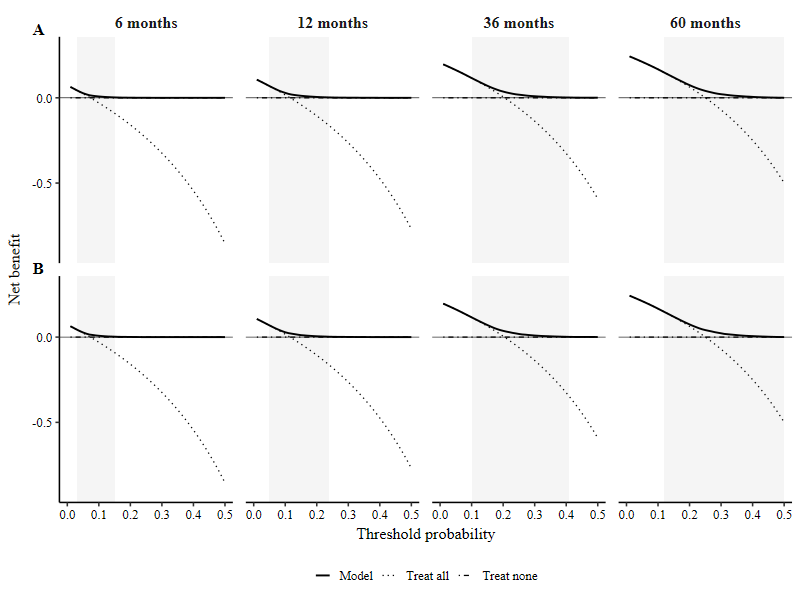

In [256]:
txt_idx <- which(vapply(
  p_dca_readm$layers,
  function(l) inherits(l$geom, "GeomText"),
  logical(1)
))[1]

p_dca_readm$layers[[txt_idx]]$data <- data.frame(
  model_panel = factor(c("A", "B"), levels = c("A", "B")),
  horizon = factor(c(6, 6), levels = c(6, 12, 36, 60)),
  label = c("A", "B"),
  x = c(-0.11, -0.11),
  y = c(0.44, 0.44)
)

p_dca_readm$layers[[txt_idx]]$mapping$x <- quote(x)
p_dca_readm$layers[[txt_idx]]$mapping$y <- quote(y)
p_dca_readm$layers[[txt_idx]]$mapping$label <- quote(label)
p_dca_readm$layers[[txt_idx]]$aes_params$hjust <- 0
p_dca_readm$layers[[txt_idx]]$aes_params$vjust <- 1

p_dca_readm

 fact_ratio <- 1.1
ggsave(
  filename = file.path(project_root, "cons/_figs/p_dca_readm.png"),
  plot = p_dca_readm,
  width = 17.8*fact_ratio, height = 12*fact_ratio, units = "cm", dpi = 600
)
ggsave(
  filename = file.path(project_root, "cons/_figs/p_dca_readm.pdf"),
  plot = p_dca_readm,
  width = 17.8*fact_ratio, height = 12*fact_ratio, units = "cm",
  device = cairo_pdf
)

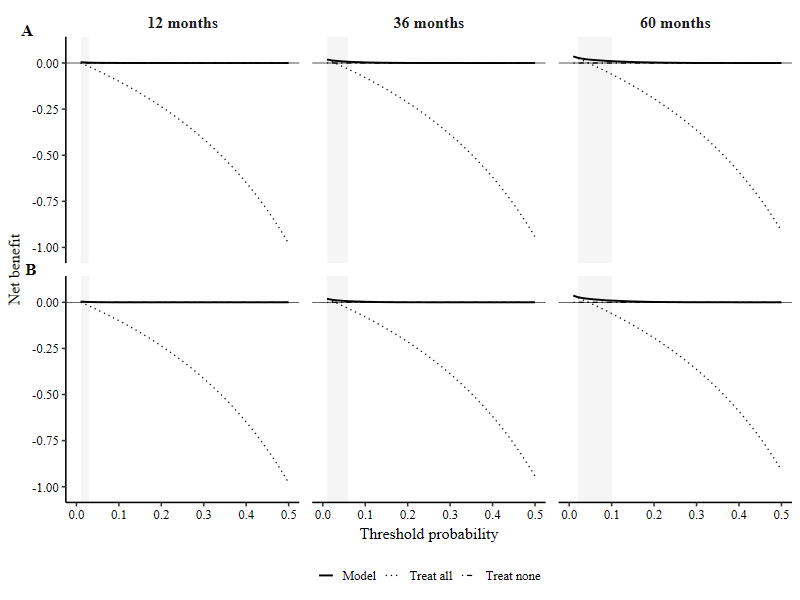

In [171]:
#| label: dca-plot-death

p_dca_death <- make_dca_panel_figure(
  summary_full = adca_out_full$summary,
  summary_ml   = adca_out$summary,
  outcome      = "death",
  horizons     = c(12, 36, 60),
  x_limits     = c(0, 0.50)#,
  #y_limits     = c(-0.80, 0.2)
)

p_dca_death
ggsave(
  filename = file.path(project_root, "cons/_figs/p_dca_death.png"),
  plot = p_dca_death,
  width = 17.8*1.2, height = 12*1.2, units = "cm", dpi = 600
)
ggsave(
  filename = file.path(project_root, "cons/_figs/p_dca_death.pdf"),
  plot = p_dca_death,
  width = 17.8*1.2, height = 12*1.2, units = "cm",
  device = cairo_pdf
)


In [ ]:
# adca_out$summary |> 
# dplyr::filter(risk == "readmission", horizon %in% c(6)) |> dput()
# c(3, 6, 9, 12, 24, 36, 48, 60, 72, 84, 96, 108) #, 12,36,60

In [131]:
#| label: nri-idi-epi

source( file.path(project_root, "cons/_hist_scripts/nri_idi_from_results_boot.R"))

reclass_out <- run_nri_idi_from_results_boot(
  results_boot_full,
  results_boot,
  old_label = "full_model",
  new_label = "spline_model"
)

NRI/IDI functions loaded. Available entry points:
  run_nri_idi_from_results_boot(results_boot, results_boot_full, ...)
  run_nri_idi_comparison(
    results_boot_cox = 'path/to/results_boot.rds',
    xgb_pickle_path = 'xgb/_out/xgb6_corr_DUAL_final_ev_hyp_20260223_2134.pkl',
    risk = 'death',  # or 'readmission'
    horizon = 12,
    cutoffs = 0.15  # X-tile determined cutoff
  )


In [132]:
#| label: nri-idi-epi-table

#rm(list = ls(pattern = "run_nri_idi"))
source(paste0(project_root,"/cons/_hist_scripts/make_nri_idi_epidemiology_table.R"))
tab_out <- make_nri_idi_epidemiology_table(reclass_out)
rownames(tab_out$table) <- NULL
nri_idi<- tab_out$table |> 
  knitr::kable(format = "html", escape = FALSE) |> 
  kableExtra::kable_styling(full_width = FALSE, position = "left", font_size = 10) |> 
  kableExtra::scroll_box(height = "350px", width = "100%")
kableExtra::save_kable(nri_idi, paste0(project_root, "/cons/_out/table_nri_idi.html"))

#cat(readLines(paste0(project_root,"/cons/_hist_scripts/table_nri_idi.html"),), sep = "\n")

## Threshold-dependent metrics (NPV, PPV, Sens, Spec)

In [270]:
#| label: threshold-metrics-function

source(paste0(project_root,"/cons/_hist_scripts/threshold_metrics_from_results_boot.R"))


threshold_spec <- list(
  death = list(
    `12` = c(0.03, 0.05),
    `36` = c(0.03, 0.05),
    `60` = c(0.03, 0.05)
  ),
  readmission = list(
    `6`  = c(0.10, 0.15, 0.20),
    `12` = c(0.10, 0.15, 0.20),
    `36` = c(0.20, 0.25),
    `60` = c(0.20, 0.25)
  )
)

cox_threshold_out <- run_threshold_metrics_from_results_boot(
  results_boot_reference = results_boot_full,
  results_boot_updated = results_boot,
  threshold_spec = threshold_spec,
  reference_label = "full_model",
  updated_label = "spline_model"
)

In [271]:
#| label: threshold-metrics

source(paste0(project_root, "/cons/_hist_scripts/plot_threshold_metrics_from_summary_long.R"))

figs_thr_metrics <- plot_threshold_metrics_separate_outcomes(
  summary_long = cox_threshold_out$summary_long,
  horizons = c(6, 12, 36, 60),
  panel_models = c("full_model", "spline_model"),
  panel_titles = c("Full model", "Spline model"),
  metrics = c("NPV", "PPV", "Sens", "Spec"), 
  save_files = FALSE
)

In [293]:
head(cox_threshold_out$summary_long)

                                   Model  Risk Time Threshold Metric       mean       q025
full_model.Death.12.0.03.F1   full_model Death   12      0.03     F1 0.10512520 0.08501266
full_model.Death.12.0.03.NPV  full_model Death   12      0.03    NPV 0.99241359 0.99144038
full_model.Death.12.0.03.PPV  full_model Death   12      0.03    PPV 0.06115073 0.04867032
full_model.Death.12.0.03.Sens full_model Death   12      0.03   Sens 0.37778585 0.33333333
full_model.Death.12.0.03.Spec full_model Death   12      0.03   Spec 0.93326375 0.92723866
full_model.Death.12.0.05.F1   full_model Death   12      0.05     F1 0.12950001 0.09333333
                                    q975  n
full_model.Death.12.0.03.F1   0.12582857 25
full_model.Death.12.0.03.NPV  0.99380457 25
full_model.Death.12.0.03.PPV  0.07528499 25
full_model.Death.12.0.03.Sens 0.45054945 25
full_model.Death.12.0.03.Spec 0.94234672 25
full_model.Death.12.0.05.F1   0.16359216 25

In [ ]:
# cox_threshold_out$summary_long |> dplyr::filter(Risk == "Readmission", Time %in% c(6, 12, 36, 60)) |> dput()
# cox_threshold_out$summary_long |> dplyr::filter(Risk == "Death", Time %in% c(12, 36, 60)) |> dput()

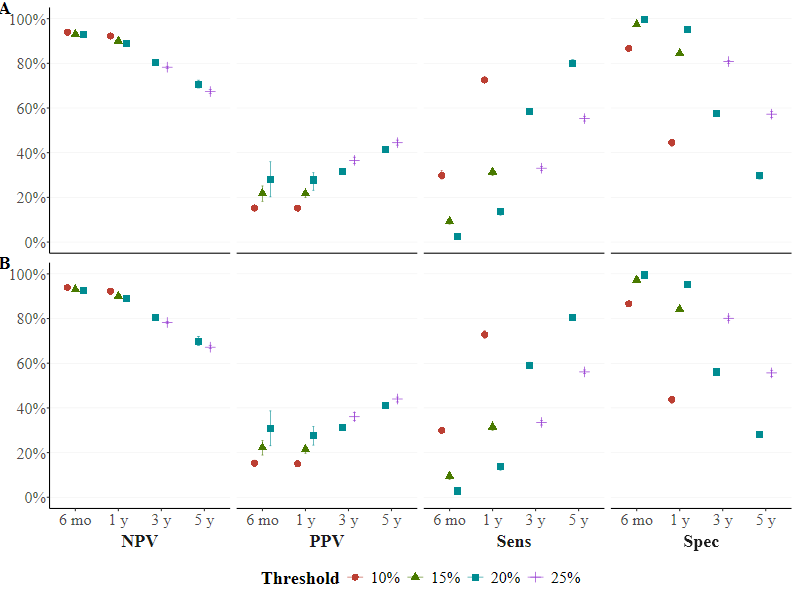

In [272]:
#| label: threshold-metrics-plot-adjust-readm

# increase title and axis label sizes (adjust numbers as needed)
figs_thr_metrics$outcomes$Readmission$model_plots$full_model<-
figs_thr_metrics$outcomes$Readmission$model_plots$full_model +
  theme(
    strip.text = element_blank(),
    plot.title   = element_text(size = 26, face = "bold", family = tnr),
    axis.title.x = element_text(size = 20, family = tnr),
    axis.title.y = element_text(size = 20, family = tnr),
    axis.text    = element_text(size = 16, family = tnr),
    legend.title = element_text(size = 18, face = "bold", family = tnr),
    legend.text  = element_text(size = 16, family = tnr),
    legend.key.size = unit(0.7, "cm"),
    legend.spacing.x = unit(0.3, "cm")
  )

figs_thr_metrics$outcomes$Readmission$model_plots$spline_model<-
figs_thr_metrics$outcomes$Readmission$model_plots$spline_model +
  theme(
    strip.text = element_text(size = 18, face = "bold", family = tnr),
    plot.title   = element_text(size = 26, face = "bold", family = tnr),
    axis.title.x = element_text(size = 20, family = tnr),
    axis.title.y = element_text(size = 20, family = tnr),
    axis.text    = element_text(size = 16, family = tnr),
    legend.title = element_text(size = 18, face = "bold", family = tnr),
    legend.text  = element_text(size = 16, family = tnr),
    legend.key.size = unit(0.7, "cm"),
    legend.spacing.x = unit(0.3, "cm")
  )

p_readm <- combine_threshold_metric_panels(
  figs_thr_metrics$outcomes$Readmission$model_plots,
  figure_title = NULL,
  figure_caption = NULL
)&
  theme(
    plot.tag = element_text(size = 18, face = "bold", family = tnr),
    plot.tag.position = c(-0.005, 1)
  )
p_readm

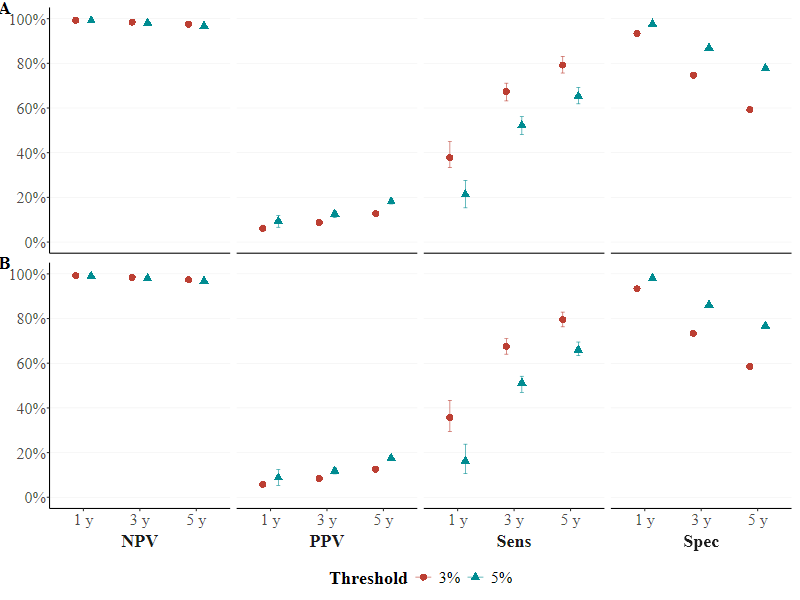

In [273]:
#| label: threshold-metrics-plot-adjust-death

# increase title and axis label sizes (adjust numbers as needed)
figs_thr_metrics$outcomes$Death$model_plots$full_model<-
figs_thr_metrics$outcomes$Death$model_plots$full_model +
  theme(
    strip.text = element_blank(),
    plot.title   = element_text(size = 26, face = "bold", family = tnr),
    axis.title.x = element_text(size = 20, family = tnr),
    axis.title.y = element_text(size = 20, family = tnr),
    axis.text    = element_text(size = 16, family = tnr),
    legend.title = element_text(size = 18, face = "bold", family = tnr),
    legend.text  = element_text(size = 16, family = tnr),
    legend.key.size = unit(0.7, "cm"),
    legend.spacing.x = unit(0.3, "cm")
  )

figs_thr_metrics$outcomes$Death$model_plots$spline_model<-
figs_thr_metrics$outcomes$Death$model_plots$spline_model +
  theme(
    strip.text = element_text(size = 18, face = "bold", family = tnr),
    plot.title   = element_text(size = 26, face = "bold", family = tnr),
    axis.title.x = element_text(size = 20, family = tnr),
    axis.title.y = element_text(size = 20, family = tnr),
    axis.text    = element_text(size = 16, family = tnr),
    legend.title = element_text(size = 18, face = "bold", family = tnr),
    legend.text  = element_text(size = 16, family = tnr),
    legend.key.size = unit(0.7, "cm"),
    legend.spacing.x = unit(0.3, "cm")
  )

p_death <- combine_threshold_metric_panels(
  figs_thr_metrics$outcomes$Death$model_plots,
  figure_title = NULL,
  figure_caption = NULL
)&
  theme(
    plot.tag = element_text(size = 18, face = "bold", family = tnr),
    plot.tag.position = c(-0.005, 1)
  )
p_death

In [274]:
#| label: threshold-metrics-plot-adjust-deathj-export

ggsave(
  file.path(project_root, "cons/_figs/p_threshold_death.pdf"),
  p_death,
  width = 20,
  height = 9,
  units = "cm",
  device = cairo_pdf
)
ggsave(
  filename = file.path(project_root, "cons/_figs/p_threshold_death.png"),
  plot = p_death,
  width = 15 * 1.3,
  height = 15 * 1.3,
  units = "cm",
  dpi = 600
)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for shape is already present.
Adding another scale for shape, which will replace the existing scale.
Scale for shape is already present.
Adding another scale for shape, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


Warning messages:
1: No shared levels found between `names(values)` of the manual scale and the data's fill values. 
2: No shared levels found between `names(values)` of the manual scale and the data's fill values. 


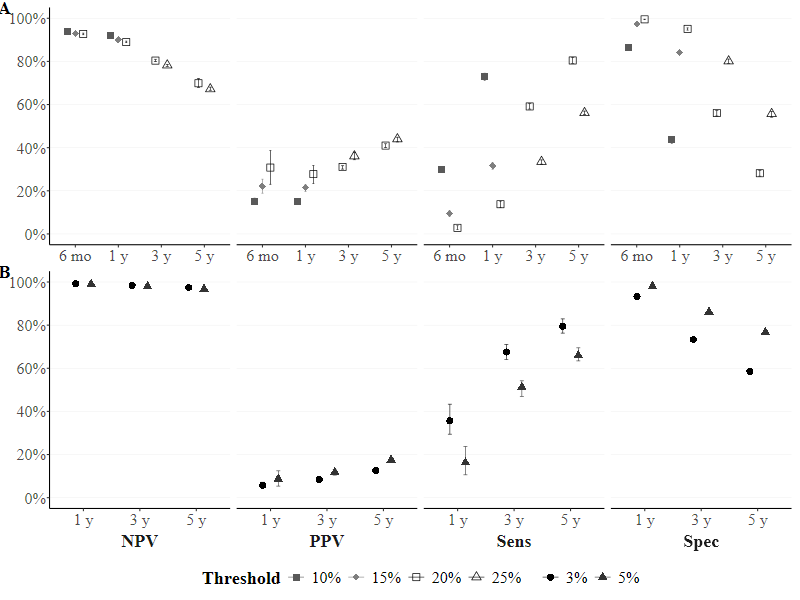

Warning messages:
1: No shared levels found between `names(values)` of the manual scale and the data's fill values. 
2: No shared levels found between `names(values)` of the manual scale and the data's fill values. 
Warning messages:
1: No shared levels found between `names(values)` of the manual scale and the data's fill values. 
2: No shared levels found between `names(values)` of the manual scale and the data's fill values. 


In [286]:
bw_shapes <- c(
  "3%"  = 16,  # filled circle
  "5%"  = 17,  # filled triangle
  "10%" = 15,  # filled square
  "15%" = 18,  # diamond
  "20%" = 0,   # open square#1,   # open circle
  "25%" = 25#2    # open triangle
)

bw_cols <- c(
  "3%"  = "black",
  "5%"  = "grey20",
  "10%" = "grey35",
  "15%" = "grey50",
  "20%" = "black",
  "25%" = "black"
)

figs_thr_metrics$outcomes$Readmission$model_plots$spline_model_mod <-
  figs_thr_metrics$outcomes$Readmission$model_plots$spline_model +
  scale_shape_manual(values = bw_shapes) +
  scale_color_manual(values = bw_cols) +
  scale_fill_manual(values = bw_cols) +
  theme(
    strip.text = element_blank(),#element_text(size = 18, face = "bold", family = tnr),
    axis.text = element_text(size = 16, family = tnr),
    legend.title = element_text(size = 18, face = "bold", family = tnr),
    legend.text = element_text(size = 16, family = tnr),
    legend.key.size = unit(0.7, "cm"),
    legend.spacing.x = unit(0.3, "cm")
  )

figs_thr_metrics$outcomes$Death$model_plots$spline_model_mod <-
  figs_thr_metrics$outcomes$Death$model_plots$spline_model +
  scale_shape_manual(values = bw_shapes) +
  scale_color_manual(values = bw_cols) +
  scale_fill_manual(values = bw_cols) +
  theme(
    strip.text = element_text(size = 18, face = "bold", family = tnr),
    axis.text = element_text(size = 16, family = tnr),
    legend.title = element_blank(),
    legend.text = element_text(size = 16, family = tnr),
    legend.key.size = unit(0.7, "cm"),
    legend.spacing.x = unit(0.3, "cm")
  )

# Define your palettes (ensure names match your data values exactly)
bw_shapes <- c(
  "3%"  = 16,  # filled circle
  "5%"  = 17,  # filled triangle
  "10%" = 15,  # filled square
  "15%" = 18,  # filled diamond
  "20%" = 0,   # open square
  "25%" = 2    # open triangle (shape 2 is standard open triangle)
)

bw_cols <- c(
  "3%"  = "black",
  "5%"  = "grey20",
  "10%" = "grey35",
  "15%" = "grey50",
  "20%" = "black",
  "25%" = "black"
)

# 1. Combine the original plots
p_comb <- combine_threshold_metric_panels(
  list(
    figs_thr_metrics$outcomes$Readmission$model_plots$spline_model_mod,
    figs_thr_metrics$outcomes$Death$model_plots$spline_model_mod
  ),
  figure_title = NULL,
  figure_caption = NULL
)

# 2. Apply scales and themes globally using '&'
# This forces the scales onto every subplot within the combined figure
p_comb <- p_comb &
  scale_shape_manual(values = bw_shapes) &
  scale_color_manual(values = bw_cols) &
  scale_fill_manual(values = bw_cols) &
  theme(
    #strip.text = element_text(size = 18, face = "bold", family = tnr),
    axis.text = element_text(size = 16, family = tnr),
    #legend.title = element_text(size = 18, face = "bold", family = tnr),
    legend.text = element_text(size = 16, family = tnr),
    legend.key.size = unit(0.7, "cm"),
    legend.spacing.x = unit(0.3, "cm"),
    plot.tag = element_text(size = 18, face = "bold", family = tnr),
    plot.tag.position = c(-0.005, 1)
  )

p_comb

ggsave(
  file.path(project_root, "cons/_figs/p_threshold_combined.pdf"),
  p_comb,
  width = 20,
  height = 17,
  units = "cm",
  device = cairo_pdf
)

ggsave(
  file.path(project_root, "cons/_figs/p_threshold_combined.png"),
  p_comb,
  width = 20,
  height = 17,
  units = "cm",
  dpi = 600
)

In [281]:
# Check the unique values in the column mapped to color/fill
unique(figs_thr_metrics$outcomes$Readmission$model_plots$spline_model$data[[
  as_label(figs_thr_metrics$outcomes$Readmission$model_plots$spline_model$mapping$colour)
]])


[1] 10% 15% 20% 25%
Levels: 10% 15% 20% 25%

In [ ]:
 #| label: threshold-metrics-table-readm

readm_thr_metrics<- subset(
  cox_threshold_out$summary_wide,
  Risk == "Readmission" 
) |> 
  knitr::kable("html", caption="Threshold metrics for readmission") |>
  kableExtra::kable_styling(full_width = FALSE, position = "left", font_size = 10) |>
  kableExtra::scroll_box(height = "350px", width = "100%")

kableExtra::save_kable(readm_thr_metrics, paste0(project_root, "/cons/_out/readm_thr_metrics.html"))

#cat(readLines(paste0(project_root,"/cons/_out/readm_thr_metrics.html"),), sep = "\n")

In [224]:
#| label: threshold-metrics-table-death
death_thr_metrics<- subset(
  cox_threshold_out$summary_wide,
  Risk == "Death" 
) |> 
  knitr::kable("html", caption="Threshold metrics for death") |>
  kableExtra::kable_styling(full_width = FALSE, position = "left", font_size = 10) |>
  kableExtra::scroll_box(height = "350px", width = "100%")

kableExtra::save_kable(death_thr_metrics, paste0(project_root, "/cons/_out/death_thres_metrics.html"))

#cat(readLines(paste0(project_root,"/cons/_out/death_thres_metrics.html"),), sep = "\n")



# Session info



In [198]:
#| label: session-info
#| echo: true
#| error: true
#| message: true
#| paged.print: true
message(paste0("R library: ", Sys.getenv("R_LIBS_USER")))
message(paste0("Date: ",withr::with_locale(new = c('LC_TIME' = 'C'), code =Sys.time())))
message(paste0("Editor context: ", path))
cat("quarto version: "); quarto::quarto_version()
sesion_info <- devtools::session_info()

library(htmltools)
tabla <- dplyr::select(
  tibble::as_tibble(sesion_info$packages),
  c(package, loadedversion, source)
) |> 
  DT::datatable(
    filter = 'top',
    colnames = c('Row number' = 1, 'Package' = 2, 'Version' = 3),
    caption = htmltools::tags$caption(
      style = 'caption-side: top; text-align: left;',
      '', htmltools::em('R packages')
    ),
    options = list(
      pageLength = 10,
      initComplete = htmlwidgets::JS(
        "function(settings, json) {",
        "$(this.api().tables().body()).css({
            'font-family': 'Helvetica Neue',
            'font-size': '70%', 
            'white-space': 'nowrap',
            'line-height': '0.75em'
        });",
        "}"
      )
    )
  )

# Guardar el HTML
htmlwidgets::saveWidget(tabla, "tabla_packages.html", selfcontained = TRUE)

# Leer y mostrar el HTML (copia esto)
#cat(readLines("tabla_packages.html"), sep = "\n")

R library: G:/My Drive/Alvacast/SISTRAT 2023/renv/library/windows/R-4.4/x86_64-w64-mingw32
Date: 2026-03-30 19:57:05.154438
Editor context: G:/My Drive/Alvacast/SISTRAT 2023/data/20241015_out/251001_c1_1025_df_prev1y.rds
quarto version: 

Warning message:
In system2("quarto", "-V", stdout = TRUE, env = paste0("TMPDIR=",  :
  running command '"quarto" TMPDIR=C:/Users/andre/AppData/Local/Temp/RtmpQrtjRQ/file6c3c6fcc22d6 -V' had status 1



Save



In [278]:
#| label: save
#| echo: true
#| error: true
#| warning: true
#| message: true
#| paged.print: true
#| results: "hold"
#| eval: true

wdpath<-
paste0(gsub("/cons","",gsub("cons","",paste0(getwd(),"/cons"))))
envpath<- if(regmatches(wdpath, regexpr("[A-Za-z]+", wdpath))=="G"){"G:/Mi unidad/Alvacast/SISTRAT 2023/"}else{"E:/Mi unidad/Alvacast/SISTRAT 2023/"}
paste0(getwd(),"/cons")
file.path(paste0(wdpath,"data/20241015_out"))
file.path(paste0(envpath,"data/20241015_out"))
# Save
rdata_path <- file.path(wdpath, "data/20241015_out", paste0("pred23_ndp_", format(Sys.time(), "%Y_%m_%d"), ".Rdata"))
save.image(rdata_path)
cat("Saved in:",
    rdata_path)
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
if (Sys.getenv("RSTUDIO_SESSION_TYPE") == "server" || file.exists("/.dockerenv")) {
  password <- Sys.getenv("PASSWORD_SECRET")
} else {
  if (interactive()) {
    utils::savehistory(tempfile())
    Sys.setenv(PASSWORD_SECRET = readLines(paste0(wdpath, "secret.txt"), warn = FALSE))
    utils::loadhistory()
  }
  Sys.setenv(PASSWORD_SECRET = readLines(paste0(wdpath, "secret.txt"), warn = FALSE))
}
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
save.image(paste0(rdata_path,".enc"))
# Encriptar el archivo en el mismo lugar
httr2::secret_encrypt_file(path = paste0(rdata_path,".enc"), key = "PASSWORD_SECRET")
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
cat("Copy renv lock into cons folder\n")
if (Sys.getenv("RSTUDIO_SESSION_TYPE") == "server" || file.exists("/.dockerenv")) {
  message("Running on RStudio Server or inside Docker. Folder copy skipped.")
} else {
    
  source_folder <- 
  destination_folder <- paste0(wdpath,"cons/renv")
  
  # Copy the folder recursively
    file.copy(paste0(wdpath,"renv.lock"), paste0(wdpath,"cons/renv.lock"), overwrite = TRUE)
  
  message("Renv lock copy performed.")
}
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
time_after_dedup2<-Sys.time()

Saved in: g:/My Drive/Alvacast/SISTRAT 2023///data/20241015_out/pred23_ndp_2026_03_30.Rdata

: [1m[33mError[39m in `aes_any()`:[22m
[33m![39m long vectors not supported yet: memory.c:3948